# Evaluating Machine Learning and Deep Learning Models for Student Placement Prediction through a GUI-Based Prototype

# Importing Libraries , Loading the dataset and Basic few operations

In [1]:
# It is used to import the pandas library for data manipulation and analysis
import pandas as pd

# It is used to import the numpy library for numerical computations
import numpy as np

# It is used to load the dataset into a pandas DataFrame
df = pd.read_csv("placementdata.csv")


# It is used to display the first five rows of the dataset
print("First 5 rows of the dataset:")
print(df.head())

# It is used to display the shape of the dataset (number of rows and columns)
print("\nShape of the dataset (rows, columns):")
print(df.shape)

# It is used to generate descriptive statistical information of numerical columns
print("\nStatistical description of the dataset:")
print(df.describe())

First 5 rows of the dataset:
   StudentID  CGPA  Internships  Projects  Workshops/Certifications  \
0          1   7.5            1         1                         1   
1          2   8.9            0         3                         2   
2          3   7.3            1         2                         2   
3          4   7.5            1         1                         2   
4          5   8.3            1         2                         2   

   AptitudeTestScore  SoftSkillsRating ExtracurricularActivities  \
0                 65               4.4                        No   
1                 90               4.0                       Yes   
2                 82               4.8                       Yes   
3                 85               4.4                       Yes   
4                 86               4.5                       Yes   

  PlacementTraining  SSC_Marks  HSC_Marks PlacementStatus  
0                No         61         79       NotPlaced  
1              

# Structure and Overview of the Dataset

# Target_Variable => "PlacementStatus"

In [2]:
# It is used to import the pandas library for data manipulation and analysis
import pandas as pd

# It is used to calculate the number of observations (rows) in the dataset
num_observations = df.shape[0]

# It is used to calculate the number of columns in the dataset
num_columns = df.shape[1]

print("Number of observations:", num_observations)
print("Number of columns:", num_columns)

# It is used to define the target variable for prediction
target_variable = "PlacementStatus"

print("\nTarget variable:", target_variable)

# It is used to identify unique categories present in the target variable
target_categories = df[target_variable].unique()

# It is used to calculate the number of categories in the target variable
num_categories = df[target_variable].nunique()

print("Number of categories in target variable:", num_categories)
print("Target variable categories:", target_categories)

# It is used to compute the number of independent variables
num_independent_variables = num_columns - 1

print("\nNumber of independent variables:", num_independent_variables)

# It is used to extract the names of independent variables
independent_variables = [col for col in df.columns if col != target_variable]

print("Independent variables:")
for var in independent_variables:
    print(var)

# It is used to display the distribution of the target variable
print("\nTarget variable distribution:")
print(df[target_variable].value_counts())

Number of observations: 10000
Number of columns: 12

Target variable: PlacementStatus
Number of categories in target variable: 2
Target variable categories: ['NotPlaced' 'Placed']

Number of independent variables: 11
Independent variables:
StudentID
CGPA
Internships
Projects
Workshops/Certifications
AptitudeTestScore
SoftSkillsRating
ExtracurricularActivities
PlacementTraining
SSC_Marks
HSC_Marks

Target variable distribution:
PlacementStatus
NotPlaced    5803
Placed       4197
Name: count, dtype: int64


# Exploratory Data Analysis (EDA) => Visualisations

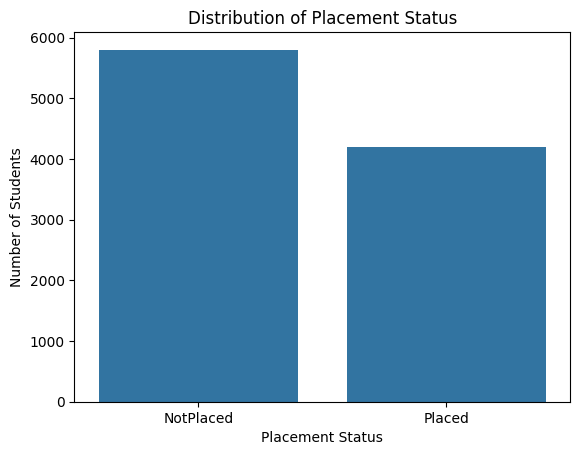

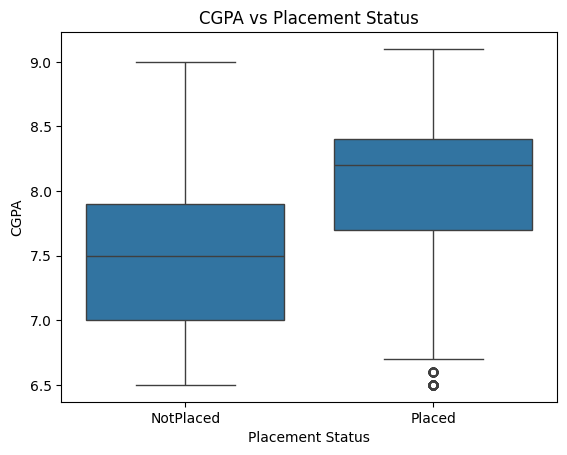

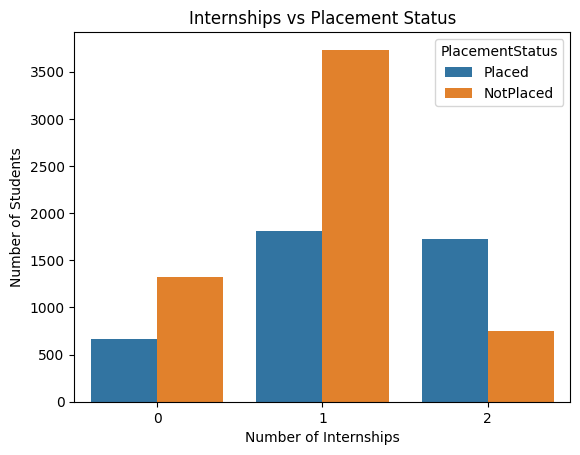

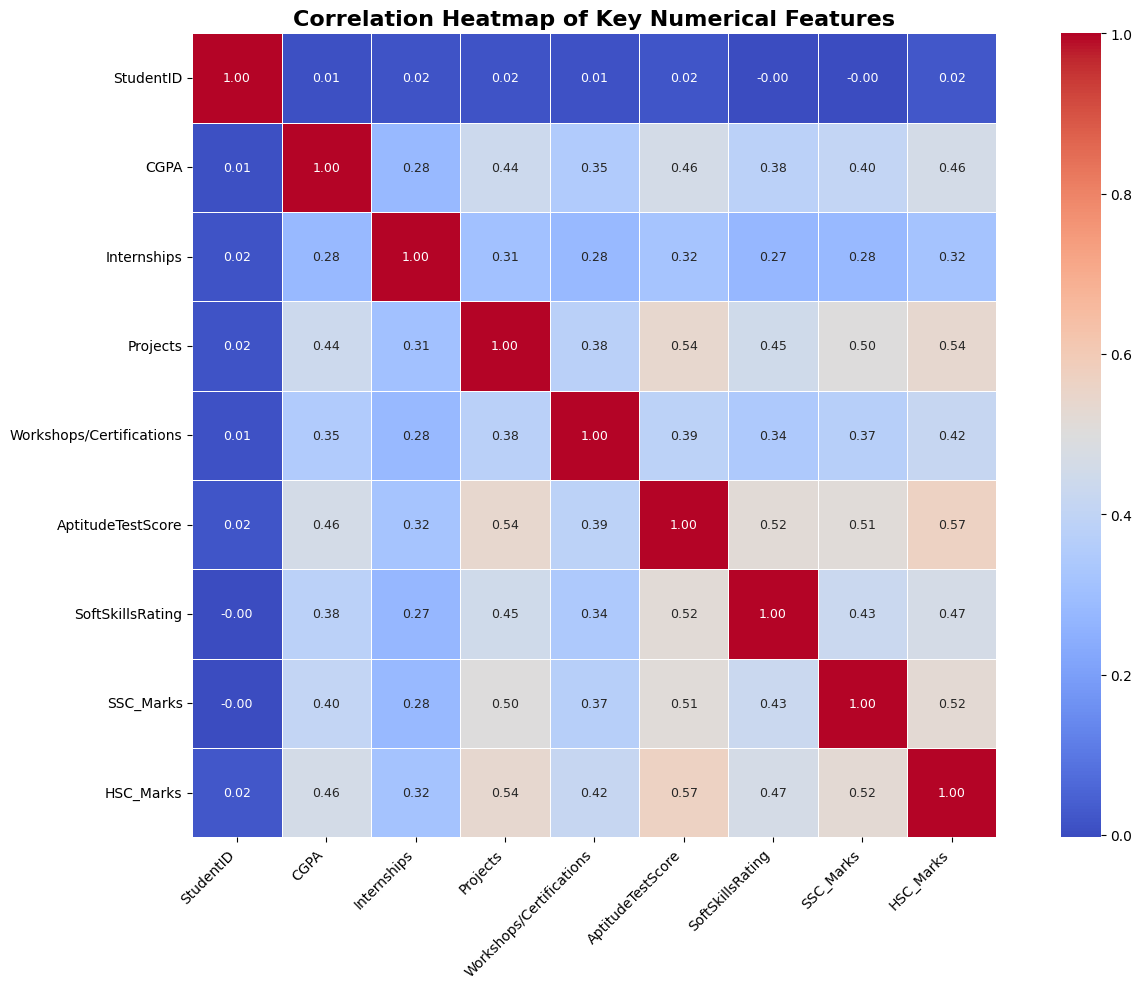

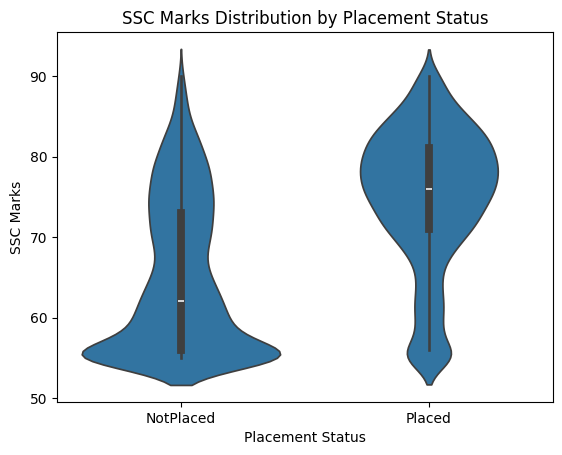

In [3]:
# It is used to import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# It is used to visualize the distribution of the target variable
sns.countplot(x="PlacementStatus", data=df)
plt.title("Distribution of Placement Status")
plt.xlabel("Placement Status")
plt.ylabel("Number of Students")
plt.show()

# It is used to visualize CGPA across placement status
sns.boxplot(x="PlacementStatus", y="CGPA", data=df)
plt.title("CGPA vs Placement Status")
plt.xlabel("Placement Status")
plt.ylabel("CGPA")
plt.show()

# It is used to visualize internship count against placement status
sns.countplot(x="Internships", hue="PlacementStatus", data=df)
plt.title("Internships vs Placement Status")
plt.xlabel("Number of Internships")
plt.ylabel("Number of Students")
plt.show()

# Select top 15 numerical features
num_cols = df.select_dtypes(include=['int64', 'float64']).columns[:15]

corr_matrix = df[num_cols].corr()

plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5,
    annot_kws={"size": 9}
)

plt.title("Correlation Heatmap of Key Numerical Features",
          fontsize=16,
          fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# It is used to visualize SSC and HSC marks based on placement status
sns.violinplot(x="PlacementStatus", y="SSC_Marks", data=df)
plt.title("SSC Marks Distribution by Placement Status")
plt.xlabel("Placement Status")
plt.ylabel("SSC Marks")
plt.show()



# Data Pre Procsssing , Feature Scaling and Splitting the dataset 

In [4]:
# I imported the Pandas library to read, organize, and manipulate the dataset in a tabular format.
import pandas as pd

# I imported the NumPy library to perform numerical operations whenever required.
import numpy as np

# I imported LabelEncoder to convert categorical values into numerical values and StandardScaler to standardize the features.
from sklearn.preprocessing import LabelEncoder, StandardScaler

# I imported train_test_split to divide the dataset into training and testing datasets.
from sklearn.model_selection import train_test_split


# I displayed a heading to indicate that I was checking for missing values before preprocessing.
print("Missing values before removal:")

# I displayed the total number of missing values present in each column of the dataset.
print(df.isnull().sum())


# I stored the total number of rows before removing missing values.
before_missing = df.shape[0]

# I removed all rows that contained missing values from the dataset.
df = df.dropna()

# I stored the total number of rows after removing missing values.
after_missing = df.shape[0]

# I displayed a confirmation message after removing the missing values.
print("\nMissing values were removed")

# I displayed the total number of rows before removing missing values.
print("Rows before removing missing values:", before_missing)

# I displayed the total number of rows after removing missing values.
print("Rows after removing missing values:", after_missing)


# I separated the independent variables by removing the target column from the dataset.
X = df.drop(columns=["PlacementStatus"])

# I selected the target variable for prediction.
y = df["PlacementStatus"]


# I created an instance of the LabelEncoder class.
label_encoder = LabelEncoder()

# I converted the target variable into numerical values using label encoding.
y = label_encoder.fit_transform(y)

# I identified all categorical columns from the independent variables.
categorical_cols = X.select_dtypes(include=['object']).columns

# I started a loop to encode each categorical column individually.
for col in categorical_cols:

    # I converted the categorical values of each column into numerical values using label encoding.
    X[col] = label_encoder.fit_transform(X[col])

# I displayed a confirmation message after completing label encoding.
print("\nLabel encoding was completed for categorical variables and target variable")


# I created an instance of the StandardScaler class.
scaler = StandardScaler()

# I standardized all independent variables so that they had a mean of 0 and a standard deviation of 1.
X_scaled = scaler.fit_transform(X)

# I displayed a confirmation message after completing feature scaling.
print("\nFeature scaling was completed using StandardScaler")


# I divided the dataset into training and testing datasets by allocating 80% for training and 20% for testing.
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# I displayed a confirmation message after completing the train-test split.
print("\nTrain-test split was completed")

# I displayed the dimensions of the training feature dataset.
print("Training feature shape:", X_train.shape)

# I displayed the dimensions of the testing feature dataset.
print("Testing feature shape:", X_test.shape)

# I displayed the dimensions of the training target dataset.
print("Training target shape:", y_train.shape)

# I displayed the dimensions of the testing target dataset.
print("Testing target shape:", y_test.shape)

Missing values before removal:
StudentID                    0
CGPA                         0
Internships                  0
Projects                     0
Workshops/Certifications     0
AptitudeTestScore            0
SoftSkillsRating             0
ExtracurricularActivities    0
PlacementTraining            0
SSC_Marks                    0
HSC_Marks                    0
PlacementStatus              0
dtype: int64

Missing values were removed
Rows before removing missing values: 10000
Rows after removing missing values: 10000

Label encoding was completed for categorical variables and target variable

Feature scaling was completed using StandardScaler

Train-test split was completed
Training feature shape: (8000, 11)
Testing feature shape: (2000, 11)
Training target shape: (8000,)
Testing target shape: (2000,)


# Class Balancing Using SMOTE => Synthetic Minority OverSampling Technique

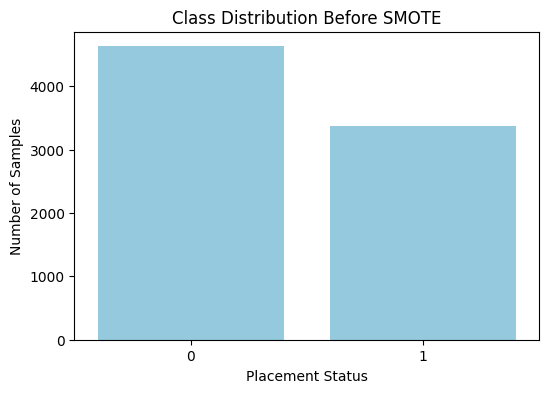

Training set shape before SMOTE: (8000, 11) (8000,)
Training set shape after SMOTE: (9262, 11) (9262,)


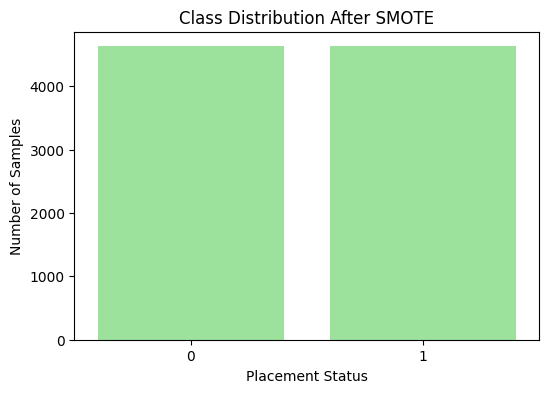

In [5]:
# I imported the SMOTE technique to handle class imbalance by generating synthetic samples for the minority class.
from imblearn.over_sampling import SMOTE

# I imported Matplotlib to create graphical visualizations of the dataset.
import matplotlib.pyplot as plt

# I imported Seaborn to create attractive statistical plots.
import seaborn as sns


# I created a new figure with a width of 6 inches and a height of 4 inches.
plt.figure(figsize=(6,4))

# I visualized the class distribution of the training dataset before applying SMOTE using a sky blue color.
sns.countplot(x=y_train, color="skyblue")

# I added a title to describe the plot.
plt.title("Class Distribution Before SMOTE")

# I labeled the x-axis as Placement Status.
plt.xlabel("Placement Status")

# I labeled the y-axis as Number of Samples.
plt.ylabel("Number of Samples")

# I displayed the class distribution plot before applying SMOTE.
plt.show()


# I created an instance of the SMOTE algorithm with a fixed random state to ensure reproducible results.
smote = SMOTE(random_state=42)

# I applied SMOTE to the training dataset to balance the class distribution by generating synthetic samples.
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# I displayed the shape of the training dataset before applying SMOTE.
print("Training set shape before SMOTE:", X_train.shape, y_train.shape)

# I displayed the shape of the training dataset after applying SMOTE.
print("Training set shape after SMOTE:", X_train_smote.shape, y_train_smote.shape)


# I created a new figure with a width of 6 inches and a height of 4 inches.
plt.figure(figsize=(6,4))

# I visualized the balanced class distribution after applying SMOTE using a light green color.
sns.countplot(x=y_train_smote, color="lightgreen")

# I added a title to describe the balanced class distribution.
plt.title("Class Distribution After SMOTE")

# I labeled the x-axis as Placement Status.
plt.xlabel("Placement Status")

# I labeled the y-axis as Number of Samples.
plt.ylabel("Number of Samples")

# I displayed the class distribution plot after applying SMOTE.
plt.show()

# Model Training and Evaluating the Models

# Baseline Models (Before Hyper Parameter Tuning)

# Machine Learnig Algorithms

# 1 : Logistic Regression

Logistic Regression Performance
Accuracy : 0.7930
Precision: 0.7221
Recall   : 0.8128
F1-Score : 0.7648
AUC-ROC  : 0.8764


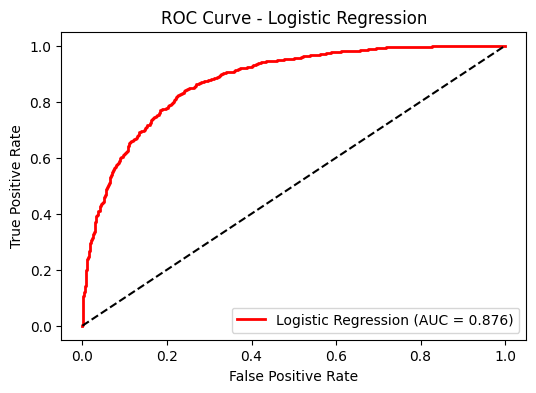


Saved Metrics
{'Model': 'Logistic Regression', 'Accuracy': 0.793, 'Precision': 0.7221030042918455, 'Recall': 0.8128019323671497, 'F1-Score': 0.7647727272727272, 'ROC-AUC': 0.8764323753936457}


In [13]:
# I imported the Logistic Regression algorithm.
from sklearn.linear_model import LogisticRegression

# I imported the required evaluation metrics.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

# I imported the visualization library.
import matplotlib.pyplot as plt

# I trained the Logistic Regression model using the SMOTE-balanced training dataset.
logistic_model = LogisticRegression(random_state=42, max_iter=1000)

# I fitted the model using the SMOTE-balanced training data.
logistic_model.fit(X_train_smote, y_train_smote)

# I generated predictions using the testing dataset.
y_pred = logistic_model.predict(X_test)

# I generated prediction probabilities for ROC-AUC analysis.
y_prob = logistic_model.predict_proba(X_test)[:, 1]

# I calculated the accuracy score.
accuracy = accuracy_score(y_test, y_pred)

# I calculated the precision score.
precision = precision_score(y_test, y_pred)

# I calculated the recall score.
recall = recall_score(y_test, y_pred)

# I calculated the F1-score.
f1 = f1_score(y_test, y_pred)

# I calculated the ROC-AUC score.
auc = roc_auc_score(y_test, y_prob)

# I saved the evaluation metrics.
baseline_lr_metrics = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1,
    "ROC-AUC": auc
}

# I printed the evaluation metrics.
print("Logistic Regression Performance")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"AUC-ROC  : {auc:.4f}")

# I calculated the False Positive Rate and True Positive Rate.
fpr, tpr, _ = roc_curve(y_test, y_prob)

# I plotted the ROC-AUC curve.
plt.figure(figsize=(6, 4))
plt.plot(
    fpr,
    tpr,
    color="red",
    linewidth=2,
    label=f"Logistic Regression (AUC = {auc:.3f})"
)

# I plotted the random classifier reference line.
plt.plot([0, 1], [0, 1], linestyle="--", color="black")

# I added the axis labels.
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

# I added the plot title.
plt.title("ROC Curve - Logistic Regression")

# I displayed the legend.
plt.legend(loc="lower right")

# I displayed the ROC curve.
plt.show()

# I displayed the saved metrics.
print("\nSaved Metrics")
print(baseline_lr_metrics)

#  2 : Random Forest

Random Forest Performance
Accuracy : 0.7860
Precision: 0.7353
Recall   : 0.7548
F1-Score : 0.7449
AUC-ROC  : 0.8673


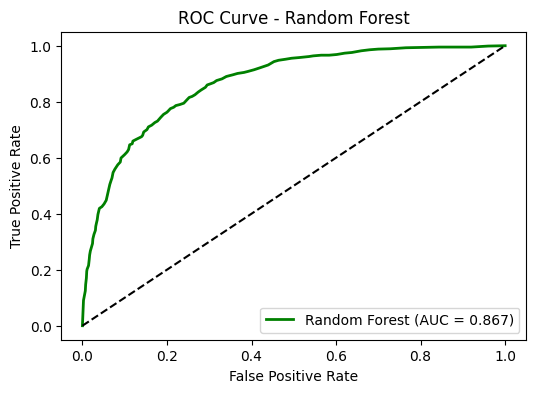


Saved Metrics
{'Model': 'Random Forest', 'Accuracy': 0.786, 'Precision': 0.7352941176470589, 'Recall': 0.7548309178743962, 'F1-Score': 0.7449344457687724, 'ROC-AUC': 0.8672821758915763}


In [14]:
# I imported the Random Forest algorithm.
from sklearn.ensemble import RandomForestClassifier

# I imported the required evaluation metrics.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

# I imported the visualization library.
import matplotlib.pyplot as plt

# I trained the Random Forest model using the SMOTE-balanced training dataset.
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# I fitted the model using the SMOTE-balanced training data.
random_forest_model.fit(X_train_smote, y_train_smote)

# I generated predictions using the testing dataset.
y_pred = random_forest_model.predict(X_test)

# I generated prediction probabilities for ROC-AUC analysis.
y_prob = random_forest_model.predict_proba(X_test)[:, 1]

# I calculated the accuracy score.
accuracy = accuracy_score(y_test, y_pred)

# I calculated the precision score.
precision = precision_score(y_test, y_pred)

# I calculated the recall score.
recall = recall_score(y_test, y_pred)

# I calculated the F1-score.
f1 = f1_score(y_test, y_pred)

# I calculated the ROC-AUC score.
auc = roc_auc_score(y_test, y_prob)

# I saved the evaluation metrics.
baseline_rf_metrics = {
    "Model": "Random Forest",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1,
    "ROC-AUC": auc
}

# I printed the evaluation metrics.
print("Random Forest Performance")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"AUC-ROC  : {auc:.4f}")

# I calculated the False Positive Rate and True Positive Rate.
fpr, tpr, _ = roc_curve(y_test, y_prob)

# I plotted the ROC-AUC curve.
plt.figure(figsize=(6, 4))
plt.plot(
    fpr,
    tpr,
    color="green",
    linewidth=2,
    label=f"Random Forest (AUC = {auc:.3f})"
)

# I plotted the random classifier reference line.
plt.plot([0, 1], [0, 1], linestyle="--", color="black")

# I added the axis labels.
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

# I added the plot title.
plt.title("ROC Curve - Random Forest")

# I displayed the legend.
plt.legend(loc="lower right")

# I displayed the ROC curve.
plt.show()

# I displayed the saved metrics.
print("\nSaved Metrics")
print(baseline_rf_metrics)

# 3 : Support Vector Machine

Support Vector Machine Performance
Accuracy : 0.7905
Precision: 0.7240
Recall   : 0.7983
F1-Score : 0.7593
AUC-ROC  : 0.8462


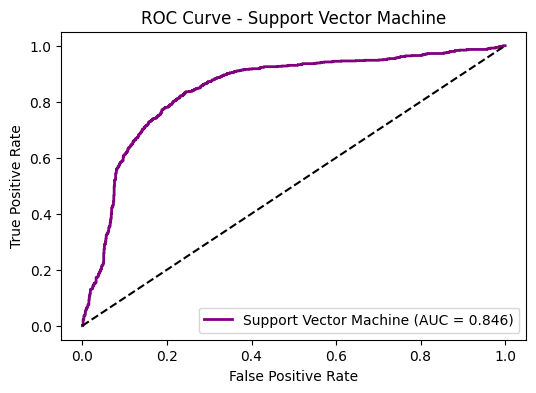


Saved Metrics
{'Model': 'Support Vector Machine', 'Accuracy': 0.7905, 'Precision': 0.723986856516977, 'Recall': 0.7983091787439613, 'F1-Score': 0.7593337162550258, 'ROC-AUC': 0.8461999802146708}


In [15]:
# I imported the Support Vector Machine algorithm.
from sklearn.svm import SVC

# I imported the required evaluation metrics.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

# I imported the visualization library.
import matplotlib.pyplot as plt

# I trained the Support Vector Machine model using the SMOTE-balanced training dataset.
svm_model = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

# I fitted the model using the SMOTE-balanced training data.
svm_model.fit(X_train_smote, y_train_smote)

# I generated predictions using the testing dataset.
y_pred = svm_model.predict(X_test)

# I generated prediction probabilities for ROC-AUC analysis.
y_prob = svm_model.predict_proba(X_test)[:, 1]

# I calculated the accuracy score.
accuracy = accuracy_score(y_test, y_pred)

# I calculated the precision score.
precision = precision_score(y_test, y_pred)

# I calculated the recall score.
recall = recall_score(y_test, y_pred)

# I calculated the F1-score.
f1 = f1_score(y_test, y_pred)

# I calculated the ROC-AUC score.
auc = roc_auc_score(y_test, y_prob)

# I saved the evaluation metrics.
baseline_svm_metrics = {
    "Model": "Support Vector Machine",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1,
    "ROC-AUC": auc
}

# I printed the evaluation metrics.
print("Support Vector Machine Performance")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"AUC-ROC  : {auc:.4f}")

# I calculated the False Positive Rate and True Positive Rate.
fpr, tpr, _ = roc_curve(y_test, y_prob)

# I plotted the ROC-AUC curve.
plt.figure(figsize=(6, 4))
plt.plot(
    fpr,
    tpr,
    color="purple",
    linewidth=2,
    label=f"Support Vector Machine (AUC = {auc:.3f})"
)

# I plotted the random classifier reference line.
plt.plot([0, 1], [0, 1], linestyle="--", color="black")

# I added the axis labels.
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

# I added the plot title.
plt.title("ROC Curve - Support Vector Machine")

# I displayed the legend.
plt.legend(loc="lower right")

# I displayed the ROC curve.
plt.show()

# I displayed the saved metrics.
print("\nSaved Metrics")
print(baseline_svm_metrics)

# Deep Learning Algorithm

#  4 : Artificial Neural Network

Epoch 1/20
232/232 [==============================] - 3s 5ms/step - loss: 0.4562 - accuracy: 0.7892 - val_loss: 0.5147 - val_accuracy: 0.7685
Epoch 2/20
232/232 [==============================] - 1s 5ms/step - loss: 0.4315 - accuracy: 0.8021 - val_loss: 0.4836 - val_accuracy: 0.7793
Epoch 3/20
232/232 [==============================] - 1s 6ms/step - loss: 0.4287 - accuracy: 0.8048 - val_loss: 0.5176 - val_accuracy: 0.7620
Epoch 4/20
232/232 [==============================] - 2s 7ms/step - loss: 0.4263 - accuracy: 0.8051 - val_loss: 0.5195 - val_accuracy: 0.7501
Epoch 5/20
232/232 [==============================] - 2s 8ms/step - loss: 0.4239 - accuracy: 0.8036 - val_loss: 0.4519 - val_accuracy: 0.7895
Epoch 6/20
232/232 [==============================] - 2s 8ms/step - loss: 0.4223 - accuracy: 0.8075 - val_loss: 0.4715 - val_accuracy: 0.7841
Epoch 7/20
232/232 [==============================] - 1s 5ms/step - loss: 0.4209 - accuracy: 0.8104 - val_loss: 0.5287 - val_accuracy: 0.7555
Epoch 

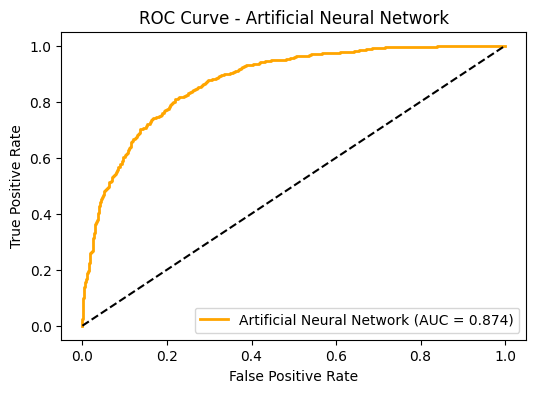


Saved Metrics
{'Model': 'Artificial Neural Network', 'Accuracy': 0.793, 'Precision': 0.7613636363636364, 'Recall': 0.7282608695652174, 'F1-Score': 0.7444444444444445, 'ROC-AUC': 0.8738963496067667}


In [16]:
# I imported the required libraries.
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# I imported the required evaluation metrics.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

# I imported the visualization library.
import matplotlib.pyplot as plt

# I created the Artificial Neural Network model.
ann_model = Sequential()

# I added the input layer and first hidden layer.
ann_model.add(Dense(64, activation="relu", input_shape=(X_train_smote.shape[1],)))

# I added the second hidden layer.
ann_model.add(Dense(32, activation="relu"))

# I added the output layer.
ann_model.add(Dense(1, activation="sigmoid"))

# I compiled the ANN model.
ann_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# I trained the ANN model using the SMOTE-balanced training dataset.
ann_model.fit(
    X_train_smote,
    y_train_smote,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# I generated prediction probabilities using the testing dataset.
y_prob = ann_model.predict(X_test).flatten()

# I converted probabilities into class predictions.
y_pred = (y_prob >= 0.5).astype(int)

# I calculated the accuracy score.
accuracy = accuracy_score(y_test, y_pred)

# I calculated the precision score.
precision = precision_score(y_test, y_pred)

# I calculated the recall score.
recall = recall_score(y_test, y_pred)

# I calculated the F1-score.
f1 = f1_score(y_test, y_pred)

# I calculated the ROC-AUC score.
auc = roc_auc_score(y_test, y_prob)

# I saved the evaluation metrics.
baseline_ann_metrics = {
    "Model": "Artificial Neural Network",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1,
    "ROC-AUC": auc
}

# I printed the evaluation metrics.
print("Artificial Neural Network Performance")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"AUC-ROC  : {auc:.4f}")

# I calculated the False Positive Rate and True Positive Rate.
fpr, tpr, _ = roc_curve(y_test, y_prob)

# I plotted the ROC-AUC curve.
plt.figure(figsize=(6, 4))
plt.plot(
    fpr,
    tpr,
    color="orange",
    linewidth=2,
    label=f"Artificial Neural Network (AUC = {auc:.3f})"
)

# I plotted the random classifier reference line.
plt.plot([0, 1], [0, 1], linestyle="--", color="black")

# I added the axis labels.
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

# I added the plot title.
plt.title("ROC Curve - Artificial Neural Network")

# I displayed the legend.
plt.legend(loc="lower right")

# I displayed the ROC curve.
plt.show()

# I displayed the saved metrics.
print("\nSaved Metrics")
print(baseline_ann_metrics)

# Comparative Comparative Table  for all Baseline  Models

In [19]:
# I imported the required libraries.
import pandas as pd
from IPython.display import display

# I created the comparative performance table.
comparison_table = pd.DataFrame([
    baseline_lr_metrics,
    baseline_rf_metrics,
    baseline_svm_metrics,
    baseline_ann_metrics
])

# I rounded the evaluation metrics.
metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]

comparison_table[metric_columns] = comparison_table[metric_columns].round(4)

# I ranked the models based on Accuracy.
comparison_table = comparison_table.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

# I inserted the ranking column.
comparison_table.insert(0, "Rank", comparison_table.index + 1)

# I created the styled table.
styled_table = (
    comparison_table.style

    # Light purple gradient.
    .background_gradient(
        cmap="Purples",
        subset=metric_columns,
        low=0.2,
        high=0.6
    )

    # Make all values black.
    .set_properties(
        subset=metric_columns,
        **{
            "color": "black",
            "font-weight": "bold"
        }
    )

    # Highlight the best value.
    .highlight_max(
        subset=metric_columns,
        color="#E6E6FA"
    )

    # Header style.
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#2F5597"),
                ("color", "white"),
                ("font-size", "14px"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("border", "1px solid #BFBFBF")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("border", "1px solid #D9D9D9"),
                ("padding", "8px"),
                ("text-align", "center"),
                ("font-size", "13px")
            ]
        },
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-size", "18px"),
                ("font-weight", "bold"),
                ("color", "#2F5597")
            ]
        }
    ])

    # Rank column.
    .set_properties(
        subset=["Rank"],
        **{
            "background-color": "#F4F1DE",
            "font-weight": "bold",
            "color": "black"
        }
    )

    # Model column.
    .set_properties(
        subset=["Model"],
        **{
            "background-color": "#F8F9FA",
            "font-weight": "bold",
            "color": "black"
        }
    )

    # Hide the index.
    .hide(axis="index")

    # Caption.
    .set_caption(
        "Comparative Performance of Baseline Machine Learning and Deep Learning Models"
    )
)

# I displayed the styled table.
display(styled_table)

Rank,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
1,Logistic Regression,0.793000,0.722100,0.812800,0.764800,0.876400
2,Artificial Neural Network,0.793000,0.761400,0.728300,0.744400,0.873900
3,Support Vector Machine,0.790500,0.724000,0.798300,0.759300,0.846200
4,Random Forest,0.786000,0.735300,0.754800,0.744900,0.867300


# Comparative Analysis of F1-Score for all Baseline Models 

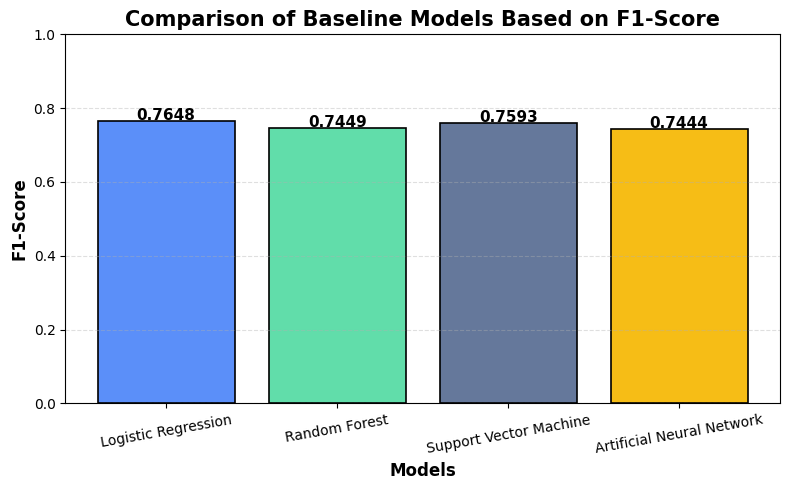

In [20]:
# I imported the required library.
import matplotlib.pyplot as plt

# I created the model names.
models = [
    baseline_lr_metrics["Model"],
    baseline_rf_metrics["Model"],
    baseline_svm_metrics["Model"],
    baseline_ann_metrics["Model"]
]

# I collected the F1-Score values.
f1_scores = [
    baseline_lr_metrics["F1-Score"],
    baseline_rf_metrics["F1-Score"],
    baseline_svm_metrics["F1-Score"],
    baseline_ann_metrics["F1-Score"]
]

# I selected professional colours for the bars.
colors = ["#5B8FF9", "#61DDAA", "#65789B", "#F6BD16"]

# I created the figure.
plt.figure(figsize=(8,5))

# I plotted the bar chart.
bars = plt.bar(
    models,
    f1_scores,
    color=colors,
    edgecolor="black",
    linewidth=1.2
)

# I displayed the F1-Score values above each bar.
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.003,
        f"{bar.get_height():.4f}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

# I added the chart title.
plt.title(
    "Comparison of Baseline Models Based on F1-Score",
    fontsize=15,
    fontweight="bold"
)

# I added the x-axis label.
plt.xlabel(
    "Models",
    fontsize=12,
    fontweight="bold"
)

# I added the y-axis label.
plt.ylabel(
    "F1-Score",
    fontsize=12,
    fontweight="bold"
)

# I set the y-axis limits.
plt.ylim(0.0, 1.0)

# I rotated the x-axis labels.
plt.xticks(rotation=10)

# I added horizontal grid lines.
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

# I adjusted the layout.
plt.tight_layout()

# I displayed the graph.
plt.show()

# Visual Analysis for each metric for all Baseline Models 

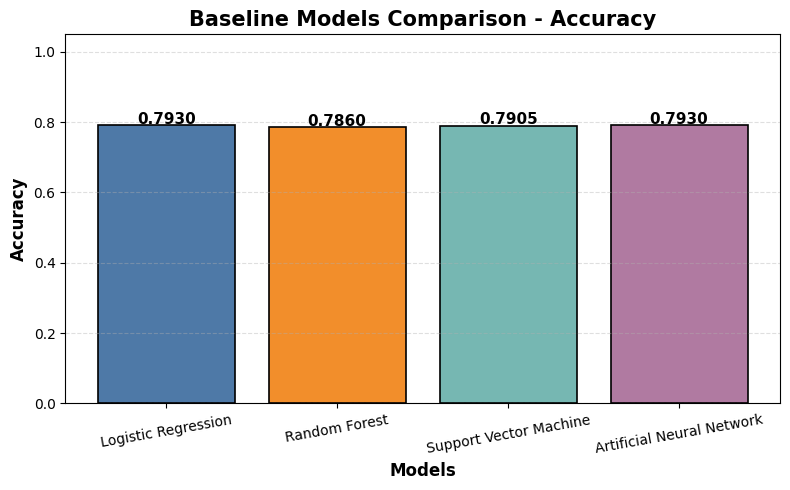

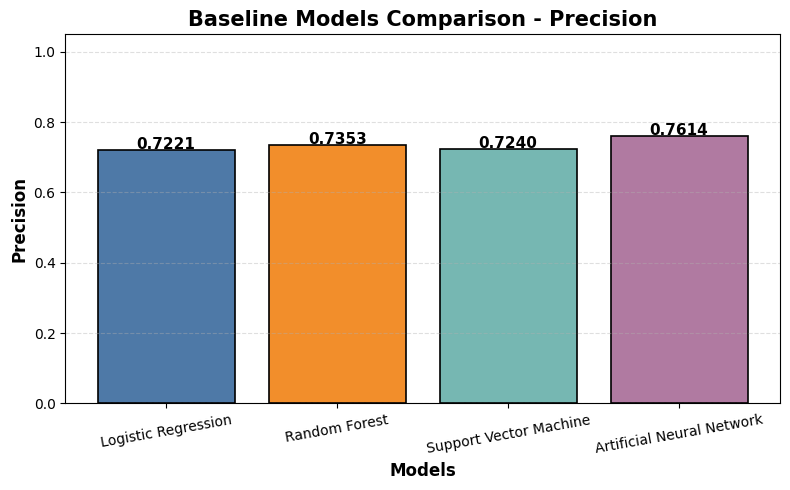

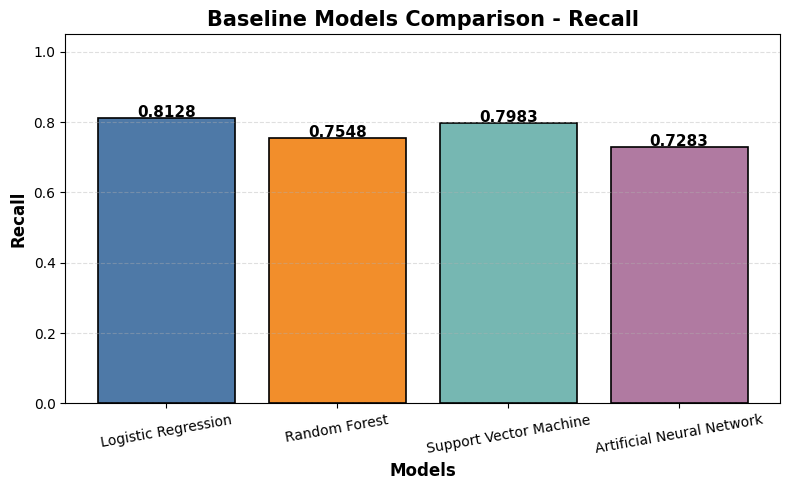

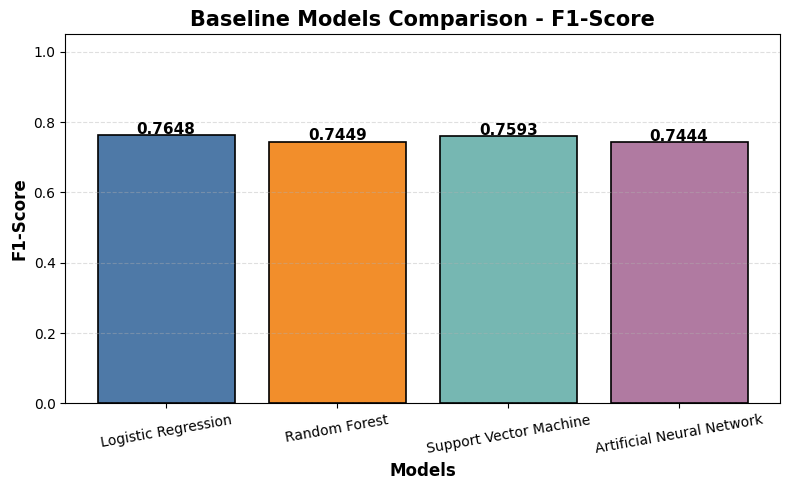

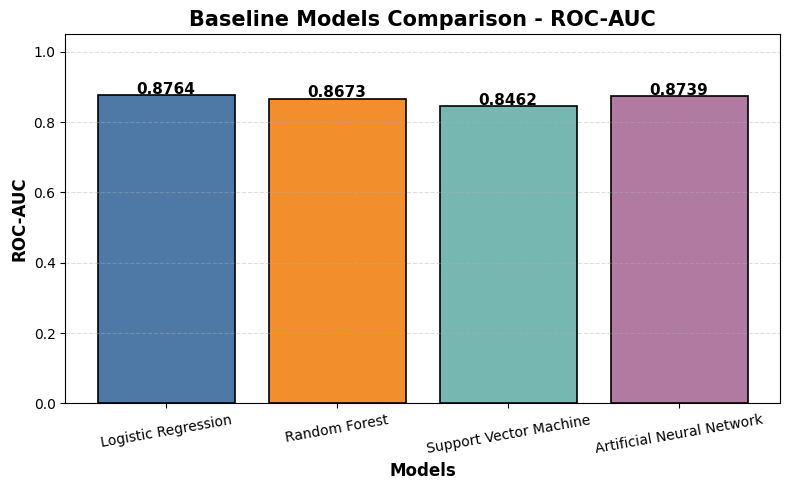

In [21]:
# I imported the required libraries.
import matplotlib.pyplot as plt

# I created the model names.
models = [
    baseline_lr_metrics["Model"],
    baseline_rf_metrics["Model"],
    baseline_svm_metrics["Model"],
    baseline_ann_metrics["Model"]
]

# I created the evaluation metrics dictionary.
metrics = {

    "Accuracy": [
        baseline_lr_metrics["Accuracy"],
        baseline_rf_metrics["Accuracy"],
        baseline_svm_metrics["Accuracy"],
        baseline_ann_metrics["Accuracy"]
    ],

    "Precision": [
        baseline_lr_metrics["Precision"],
        baseline_rf_metrics["Precision"],
        baseline_svm_metrics["Precision"],
        baseline_ann_metrics["Precision"]
    ],

    "Recall": [
        baseline_lr_metrics["Recall"],
        baseline_rf_metrics["Recall"],
        baseline_svm_metrics["Recall"],
        baseline_ann_metrics["Recall"]
    ],

    "F1-Score": [
        baseline_lr_metrics["F1-Score"],
        baseline_rf_metrics["F1-Score"],
        baseline_svm_metrics["F1-Score"],
        baseline_ann_metrics["F1-Score"]
    ],

    "ROC-AUC": [
        baseline_lr_metrics["ROC-AUC"],
        baseline_rf_metrics["ROC-AUC"],
        baseline_svm_metrics["ROC-AUC"],
        baseline_ann_metrics["ROC-AUC"]
    ]

}

# I created a colour palette.
colors = ["#4E79A7", "#F28E2B", "#76B7B2", "#B07AA1"]

# I plotted each evaluation metric.
for metric_name, values in metrics.items():

    plt.figure(figsize=(8,5))

    bars = plt.bar(
        models,
        values,
        color=colors,
        edgecolor="black",
        linewidth=1.2
    )

    # I displayed the values on each bar.
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.003,
            f"{height:.4f}",
            ha="center",
            fontsize=11,
            fontweight="bold"
        )

    plt.title(
        f"Baseline Models Comparison - {metric_name}",
        fontsize=15,
        fontweight="bold"
    )

    plt.xlabel(
        "Models",
        fontsize=12,
        fontweight="bold"
    )

    plt.ylabel(
        metric_name,
        fontsize=12,
        fontweight="bold"
    )

    plt.ylim(0.0, 1.05)

    plt.xticks(rotation=10)

    plt.grid(
        axis="y",
        linestyle="--",
        alpha=0.4
    )

    plt.tight_layout()

    plt.show()

# Combined Bar Graph for all Baseline Models 

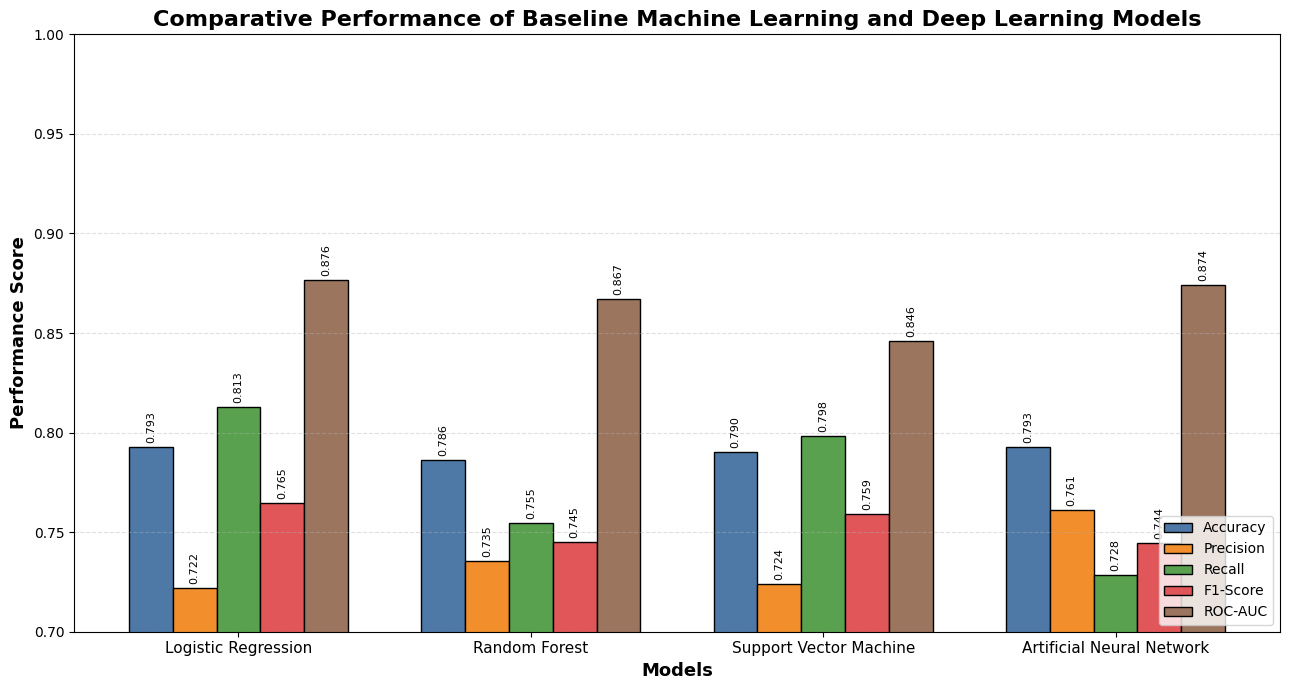

In [24]:
# I imported the required libraries.
import numpy as np
import matplotlib.pyplot as plt

# I created the model names.
models = [
    baseline_lr_metrics["Model"],
    baseline_rf_metrics["Model"],
    baseline_svm_metrics["Model"],
    baseline_ann_metrics["Model"]
]

# I collected the evaluation metrics.
accuracy = [
    baseline_lr_metrics["Accuracy"],
    baseline_rf_metrics["Accuracy"],
    baseline_svm_metrics["Accuracy"],
    baseline_ann_metrics["Accuracy"]
]

precision = [
    baseline_lr_metrics["Precision"],
    baseline_rf_metrics["Precision"],
    baseline_svm_metrics["Precision"],
    baseline_ann_metrics["Precision"]
]

recall = [
    baseline_lr_metrics["Recall"],
    baseline_rf_metrics["Recall"],
    baseline_svm_metrics["Recall"],
    baseline_ann_metrics["Recall"]
]

f1_score = [
    baseline_lr_metrics["F1-Score"],
    baseline_rf_metrics["F1-Score"],
    baseline_svm_metrics["F1-Score"],
    baseline_ann_metrics["F1-Score"]
]

roc_auc = [
    baseline_lr_metrics["ROC-AUC"],
    baseline_rf_metrics["ROC-AUC"],
    baseline_svm_metrics["ROC-AUC"],
    baseline_ann_metrics["ROC-AUC"]
]

# I created the x-axis positions.
x = np.arange(len(models))
width = 0.15

# I created the figure.
plt.figure(figsize=(13,7))

# I plotted the grouped bars.
bars1 = plt.bar(x - 2*width, accuracy,  width, label="Accuracy",  color="#4E79A7", edgecolor="black")
bars2 = plt.bar(x - width, precision, width, label="Precision", color="#F28E2B", edgecolor="black")
bars3 = plt.bar(x, recall, width, label="Recall", color="#59A14F", edgecolor="black")
bars4 = plt.bar(x + width, f1_score, width, label="F1-Score", color="#E15759", edgecolor="black")
bars5 = plt.bar(x + 2*width, roc_auc, width, label="ROC-AUC", color="#9C755F", edgecolor="black")

# I displayed the values above each bar.
for bars in [bars1, bars2, bars3, bars4, bars5]:
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.002,
            f"{bar.get_height():.3f}",
            ha="center",
            va="bottom",
            fontsize=8,
            rotation=90
        )

# I added the chart title.
plt.title(
    "Comparative Performance of Baseline Machine Learning and Deep Learning Models",
    fontsize=16,
    fontweight="bold"
)

# I added axis labels.
plt.xlabel(
    "Models",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "Performance Score",
    fontsize=13,
    fontweight="bold"
)

# I formatted the x-axis.
plt.xticks(x, models, fontsize=11)

# I set the y-axis limits.
plt.ylim(0.70, 1.00)

# I added grid lines.
plt.grid(axis="y", linestyle="--", alpha=0.4)

# I added the legend.
plt.legend(
    loc="lower right",
    fontsize=10,
    frameon=True
)

# I adjusted the layout.
plt.tight_layout()

# I displayed the graph.
plt.show()

# AUC-ROC Curve For all Baseline  Models

63/63 [==============================] - 0s 4ms/step


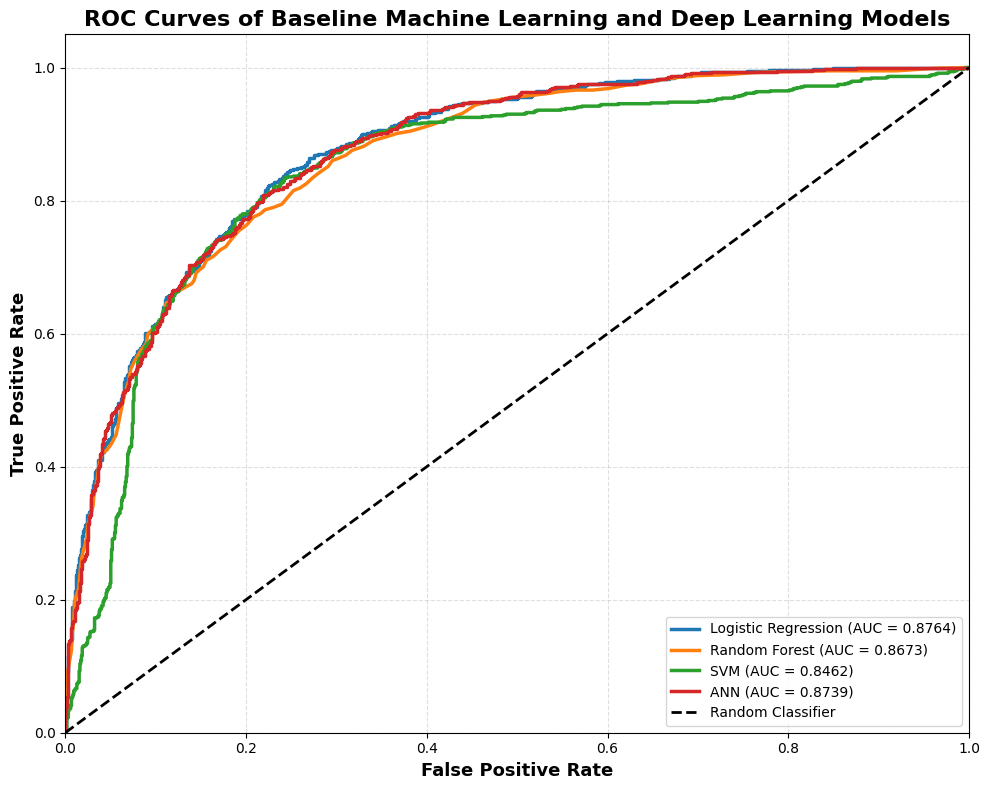

In [32]:
# I imported the required libraries.
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# I created the figure.
plt.figure(figsize=(10,8))

# Logistic Regression
y_prob = logistic_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(
    fpr,
    tpr,
    linewidth=2.5,
    label=f"Logistic Regression (AUC = {roc_auc:.4f})"
)

# Random Forest
y_prob = random_forest_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(
    fpr,
    tpr,
    linewidth=2.5,
    label=f"Random Forest (AUC = {roc_auc:.4f})"
)

# Support Vector Machine
y_prob = svm_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(
    fpr,
    tpr,
    linewidth=2.5,
    label=f"SVM (AUC = {roc_auc:.4f})"
)

# Artificial Neural Network
y_prob = ann_model.predict(X_test).ravel()
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(
    fpr,
    tpr,
    linewidth=2.5,
    label=f"ANN (AUC = {roc_auc:.4f})"
)

# Random Classifier
plt.plot(
    [0, 1],
    [0, 1],
    'k--',
    linewidth=2,
    label='Random Classifier'
)

# Formatting
plt.title(
    "ROC Curves of Baseline Machine Learning and Deep Learning Models",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "False Positive Rate",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "True Positive Rate",
    fontsize=13,
    fontweight="bold"
)

plt.xlim([0, 1])
plt.ylim([0, 1.05])

plt.grid(True, linestyle="--", alpha=0.4)

plt.legend(
    loc="lower right",
    fontsize=10,
    frameon=True
)

plt.tight_layout()
plt.show()

# Hyper Parameter Tuning 

# 1. Tuned Logistic Regression 

In [30]:
# I imported the required libraries.
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# I defined the hyperparameter grid.
lr_param_grid = {
    "C": [0.1, 1, 10],
    "solver": ["liblinear"],
    "max_iter": [100, 200]
}

# I created the Logistic Regression model.
lr_model = LogisticRegression(random_state=42)

# I performed Grid Search Cross-Validation.
lr_grid = GridSearchCV(
    estimator=lr_model,
    param_grid=lr_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    return_train_score=True
)

# I trained the model.
lr_grid.fit(X_train_smote, y_train_smote)

# I obtained the best model.
best_lr_model = lr_grid.best_estimator_

# I predicted the test data.
y_pred = best_lr_model.predict(X_test)
y_prob = best_lr_model.predict_proba(X_test)[:, 1]

# I calculated the evaluation metrics.
tuned_lr_accuracy = accuracy_score(y_test, y_pred)
tuned_lr_precision = precision_score(y_test, y_pred)
tuned_lr_recall = recall_score(y_test, y_pred)
tuned_lr_f1 = f1_score(y_test, y_pred)
tuned_lr_roc_auc = roc_auc_score(y_test, y_prob)

# I stored the cross-validation accuracy.
tuned_lr_cv_accuracy = lr_grid.best_score_

# I displayed the best hyperparameters.
print("Best Hyperparameters:")
print(lr_grid.best_params_)

# I displayed the cross-validation accuracy.
print("\nCross-Validation Accuracy:", round(tuned_lr_cv_accuracy, 4))

# I displayed the evaluation metrics.
print("\nLogistic Regression (Tuned) Performance")
print("Accuracy :", round(tuned_lr_accuracy, 4))
print("Precision:", round(tuned_lr_precision, 4))
print("Recall   :", round(tuned_lr_recall, 4))
print("F1-Score :", round(tuned_lr_f1, 4))
print("ROC-AUC  :", round(tuned_lr_roc_auc, 4))

# I displayed the classification report.
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# I stored the evaluation metrics.
tuned_lr_metrics = {
    "Model": "Logistic Regression (Tuned)",
    "Cross-Validation Accuracy": tuned_lr_cv_accuracy,
    "Accuracy": tuned_lr_accuracy,
    "Precision": tuned_lr_precision,
    "Recall": tuned_lr_recall,
    "F1-Score": tuned_lr_f1,
    "ROC-AUC": tuned_lr_roc_auc
}

Best Hyperparameters:
{'C': 1, 'max_iter': 100, 'solver': 'liblinear'}

Cross-Validation Accuracy: 0.7983

Logistic Regression (Tuned) Performance
Accuracy : 0.793
Precision: 0.7221
Recall   : 0.8128
F1-Score : 0.7648
ROC-AUC  : 0.8764

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.78      0.82      1172
           1       0.72      0.81      0.76       828

    accuracy                           0.79      2000
   macro avg       0.79      0.80      0.79      2000
weighted avg       0.80      0.79      0.79      2000



# 2. Tuned Random Forest 

In [31]:
# I imported the required libraries.
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# I defined the hyperparameter grid.
rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20],
    "min_samples_split": [2, 5]
}

# I created the Random Forest model.
rf_model = RandomForestClassifier(random_state=42)

# I performed Grid Search Cross-Validation.
rf_grid = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    return_train_score=True
)

# I trained the model.
rf_grid.fit(X_train_smote, y_train_smote)

# I obtained the best model.
best_rf_model = rf_grid.best_estimator_

# I predicted the test data.
y_pred = best_rf_model.predict(X_test)
y_prob = best_rf_model.predict_proba(X_test)[:, 1]

# I calculated the evaluation metrics.
tuned_rf_accuracy = accuracy_score(y_test, y_pred)
tuned_rf_precision = precision_score(y_test, y_pred)
tuned_rf_recall = recall_score(y_test, y_pred)
tuned_rf_f1 = f1_score(y_test, y_pred)
tuned_rf_roc_auc = roc_auc_score(y_test, y_prob)

# I stored the cross-validation accuracy.
tuned_rf_cv_accuracy = rf_grid.best_score_

# I displayed the best hyperparameters.
print("Best Hyperparameters:")
print(rf_grid.best_params_)

# I displayed the cross-validation accuracy.
print("\nCross-Validation Accuracy:", round(tuned_rf_cv_accuracy, 4))

# I displayed the evaluation metrics.
print("\nRandom Forest (Tuned) Performance")
print("Accuracy :", round(tuned_rf_accuracy, 4))
print("Precision:", round(tuned_rf_precision, 4))
print("Recall   :", round(tuned_rf_recall, 4))
print("F1-Score :", round(tuned_rf_f1, 4))
print("ROC-AUC  :", round(tuned_rf_roc_auc, 4))

# I displayed the classification report.
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# I stored the evaluation metrics.
tuned_rf_metrics = {
    "Model": "Random Forest (Tuned)",
    "Cross-Validation Accuracy": tuned_rf_cv_accuracy,
    "Accuracy": tuned_rf_accuracy,
    "Precision": tuned_rf_precision,
    "Recall": tuned_rf_recall,
    "F1-Score": tuned_rf_f1,
    "ROC-AUC": tuned_rf_roc_auc
}

Best Hyperparameters:
{'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}

Cross-Validation Accuracy: 0.8201

Random Forest (Tuned) Performance
Accuracy : 0.7925
Precision: 0.7444
Recall   : 0.7597
F1-Score : 0.7519
ROC-AUC  : 0.871

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.82      0.82      1172
           1       0.74      0.76      0.75       828

    accuracy                           0.79      2000
   macro avg       0.79      0.79      0.79      2000
weighted avg       0.79      0.79      0.79      2000



# 3. Tuned SVM 

In [33]:
# I imported the required libraries.
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# I defined the hyperparameter grid.
svm_param_grid = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf"]
}

# I created the Support Vector Machine model.
svm_model = SVC(
    probability=True,
    random_state=42
)

# I performed Grid Search Cross-Validation.
svm_grid = GridSearchCV(
    estimator=svm_model,
    param_grid=svm_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    return_train_score=True
)

# I trained the model.
svm_grid.fit(X_train_smote, y_train_smote)

# I obtained the best model.
best_svm_model = svm_grid.best_estimator_

# I predicted the test data.
y_pred = best_svm_model.predict(X_test)
y_prob = best_svm_model.predict_proba(X_test)[:, 1]

# I calculated the evaluation metrics.
tuned_svm_accuracy = accuracy_score(y_test, y_pred)
tuned_svm_precision = precision_score(y_test, y_pred)
tuned_svm_recall = recall_score(y_test, y_pred)
tuned_svm_f1 = f1_score(y_test, y_pred)
tuned_svm_roc_auc = roc_auc_score(y_test, y_prob)

# I stored the cross-validation accuracy.
tuned_svm_cv_accuracy = svm_grid.best_score_

# I displayed the best hyperparameters.
print("Best Hyperparameters:")
print(svm_grid.best_params_)

# I displayed the cross-validation accuracy.
print("\nCross-Validation Accuracy:", round(tuned_svm_cv_accuracy, 4))

# I displayed the evaluation metrics.
print("\nSupport Vector Machine (Tuned) Performance")
print("Accuracy :", round(tuned_svm_accuracy, 4))
print("Precision:", round(tuned_svm_precision, 4))
print("Recall   :", round(tuned_svm_recall, 4))
print("F1-Score :", round(tuned_svm_f1, 4))
print("ROC-AUC  :", round(tuned_svm_roc_auc, 4))

# I displayed the classification report.
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# I stored the evaluation metrics.
tuned_svm_metrics = {
    "Model": "Support Vector Machine (Tuned)",
    "Cross-Validation Accuracy": tuned_svm_cv_accuracy,
    "Accuracy": tuned_svm_accuracy,
    "Precision": tuned_svm_precision,
    "Recall": tuned_svm_recall,
    "F1-Score": tuned_svm_f1,
    "ROC-AUC": tuned_svm_roc_auc
}

Best Hyperparameters:
{'C': 10, 'kernel': 'rbf'}

Cross-Validation Accuracy: 0.8019

Support Vector Machine (Tuned) Performance
Accuracy : 0.786
Precision: 0.7169
Recall   : 0.7983
F1-Score : 0.7554
ROC-AUC  : 0.834

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.78      0.81      1172
           1       0.72      0.80      0.76       828

    accuracy                           0.79      2000
   macro avg       0.78      0.79      0.78      2000
weighted avg       0.79      0.79      0.79      2000



# 4. Tuned ANN

In [34]:
# I imported the required libraries.
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# I defined the hyperparameters.
batch_size = 32
epochs = 20
learning_rate = 0.001

# I created the Artificial Neural Network model.
ann_model = Sequential()

ann_model.add(Dense(64, activation="relu", input_shape=(X_train_smote.shape[1],)))
ann_model.add(Dense(32, activation="relu"))
ann_model.add(Dense(1, activation="sigmoid"))

# I compiled the model.
ann_model.compile(
    optimizer=Adam(learning_rate=learning_rate),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# I trained the model.
history = ann_model.fit(
    X_train_smote,
    y_train_smote,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.2,
    verbose=1
)

# I obtained the best cross-validation (validation) accuracy.
tuned_ann_cv_accuracy = max(history.history["val_accuracy"])

# I predicted the test data.
y_prob = ann_model.predict(X_test).ravel()
y_pred = (y_prob >= 0.5).astype(int)

# I calculated the evaluation metrics.
tuned_ann_accuracy = accuracy_score(y_test, y_pred)
tuned_ann_precision = precision_score(y_test, y_pred)
tuned_ann_recall = recall_score(y_test, y_pred)
tuned_ann_f1 = f1_score(y_test, y_pred)
tuned_ann_roc_auc = roc_auc_score(y_test, y_prob)

# I displayed the best hyperparameters.
print("Best Hyperparameters:")
print({
    "Batch Size": batch_size,
    "Epochs": epochs,
    "Learning Rate": learning_rate
})

# I displayed the validation accuracy.
print("\nValidation Accuracy:", round(tuned_ann_cv_accuracy, 4))

# I displayed the evaluation metrics.
print("\nArtificial Neural Network (Tuned) Performance")
print("Accuracy :", round(tuned_ann_accuracy, 4))
print("Precision:", round(tuned_ann_precision, 4))
print("Recall   :", round(tuned_ann_recall, 4))
print("F1-Score :", round(tuned_ann_f1, 4))
print("ROC-AUC  :", round(tuned_ann_roc_auc, 4))

# I displayed the classification report.
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# I stored the evaluation metrics.
tuned_ann_metrics = {
    "Model": "Artificial Neural Network (Tuned)",
    "Validation Accuracy": tuned_ann_cv_accuracy,
    "Accuracy": tuned_ann_accuracy,
    "Precision": tuned_ann_precision,
    "Recall": tuned_ann_recall,
    "F1-Score": tuned_ann_f1,
    "ROC-AUC": tuned_ann_roc_auc
}

Epoch 1/20
232/232 [==============================] - 4s 8ms/step - loss: 0.4523 - accuracy: 0.7890 - val_loss: 0.4796 - val_accuracy: 0.7868
Epoch 2/20
232/232 [==============================] - 1s 6ms/step - loss: 0.4317 - accuracy: 0.8009 - val_loss: 0.4584 - val_accuracy: 0.7890
Epoch 3/20
232/232 [==============================] - 1s 6ms/step - loss: 0.4273 - accuracy: 0.8055 - val_loss: 0.5169 - val_accuracy: 0.7577
Epoch 4/20
232/232 [==============================] - 1s 6ms/step - loss: 0.4242 - accuracy: 0.8062 - val_loss: 0.4920 - val_accuracy: 0.7717
Epoch 5/20
232/232 [==============================] - 1s 5ms/step - loss: 0.4231 - accuracy: 0.8083 - val_loss: 0.4989 - val_accuracy: 0.7615
Epoch 6/20
232/232 [==============================] - 1s 6ms/step - loss: 0.4207 - accuracy: 0.8075 - val_loss: 0.4757 - val_accuracy: 0.7820
Epoch 7/20
232/232 [==============================] - 1s 6ms/step - loss: 0.4185 - accuracy: 0.8097 - val_loss: 0.4729 - val_accuracy: 0.7858
Epoch 

# Combined Comparative Table for all Tuned Models 

In [36]:
# I imported the required libraries.
import pandas as pd
from IPython.display import display

# I created the comparative performance table.
comparison_table = pd.DataFrame([

    tuned_lr_metrics,
    tuned_rf_metrics,
    tuned_svm_metrics,
    tuned_ann_metrics

])

# I arranged the columns.
comparison_table = comparison_table[[
    "Model",
    "Cross-Validation Accuracy",
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]]

# I rounded the evaluation metrics.
metric_columns = [
    "Cross-Validation Accuracy",
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]

comparison_table[metric_columns] = comparison_table[metric_columns].round(4)

# I ranked the models based on Accuracy.
comparison_table = comparison_table.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

comparison_table.insert(0, "Rank", comparison_table.index + 1)

# I applied professional formatting.
styled_table = (
    comparison_table.style
    .format({
        "Cross-Validation Accuracy": "{:.4f}",
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
    .highlight_max(
        subset=metric_columns,
        color="#FFF2CC"
    )
    .set_properties(
        subset=["Rank"],
        **{
            "text-align": "center",
            "font-weight": "bold",
            "border": "1px solid black"
        }
    )
    .set_properties(
        subset=["Model"],
        **{
            "text-align": "left",
            "font-weight": "bold",
            "border": "1px solid black"
        }
    )
    .set_properties(
        subset=metric_columns,
        **{
            "text-align": "center",
            "border": "1px solid black"
        }
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#1F4E78"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("border", "1px solid black"),
                ("padding", "8px")
            ]
        },
        {
            "selector": "tbody tr:nth-child(even)",
            "props": [
                ("background-color", "#F8F9FA")
            ]
        },
        {
            "selector": "tbody tr:nth-child(odd)",
            "props": [
                ("background-color", "white")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("padding", "8px")
            ]
        }
    ])
)

# I displayed the comparative performance table.
display(styled_table)

,Rank,Model,Cross-Validation Accuracy,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,1,Logistic Regression (Tuned),0.7983,0.7930,0.7221,0.8128,0.7648,0.8764
1,2,Random Forest (Tuned),0.8201,0.7925,0.7444,0.7597,0.7519,0.8710
2,3,Artificial Neural Network (Tuned),nan,0.7865,0.7574,0.7126,0.7343,0.8728
3,4,Support Vector Machine (Tuned),0.8019,0.7860,0.7169,0.7983,0.7554,0.8340


# Visual Analysis for each metric for all Tuned Models 

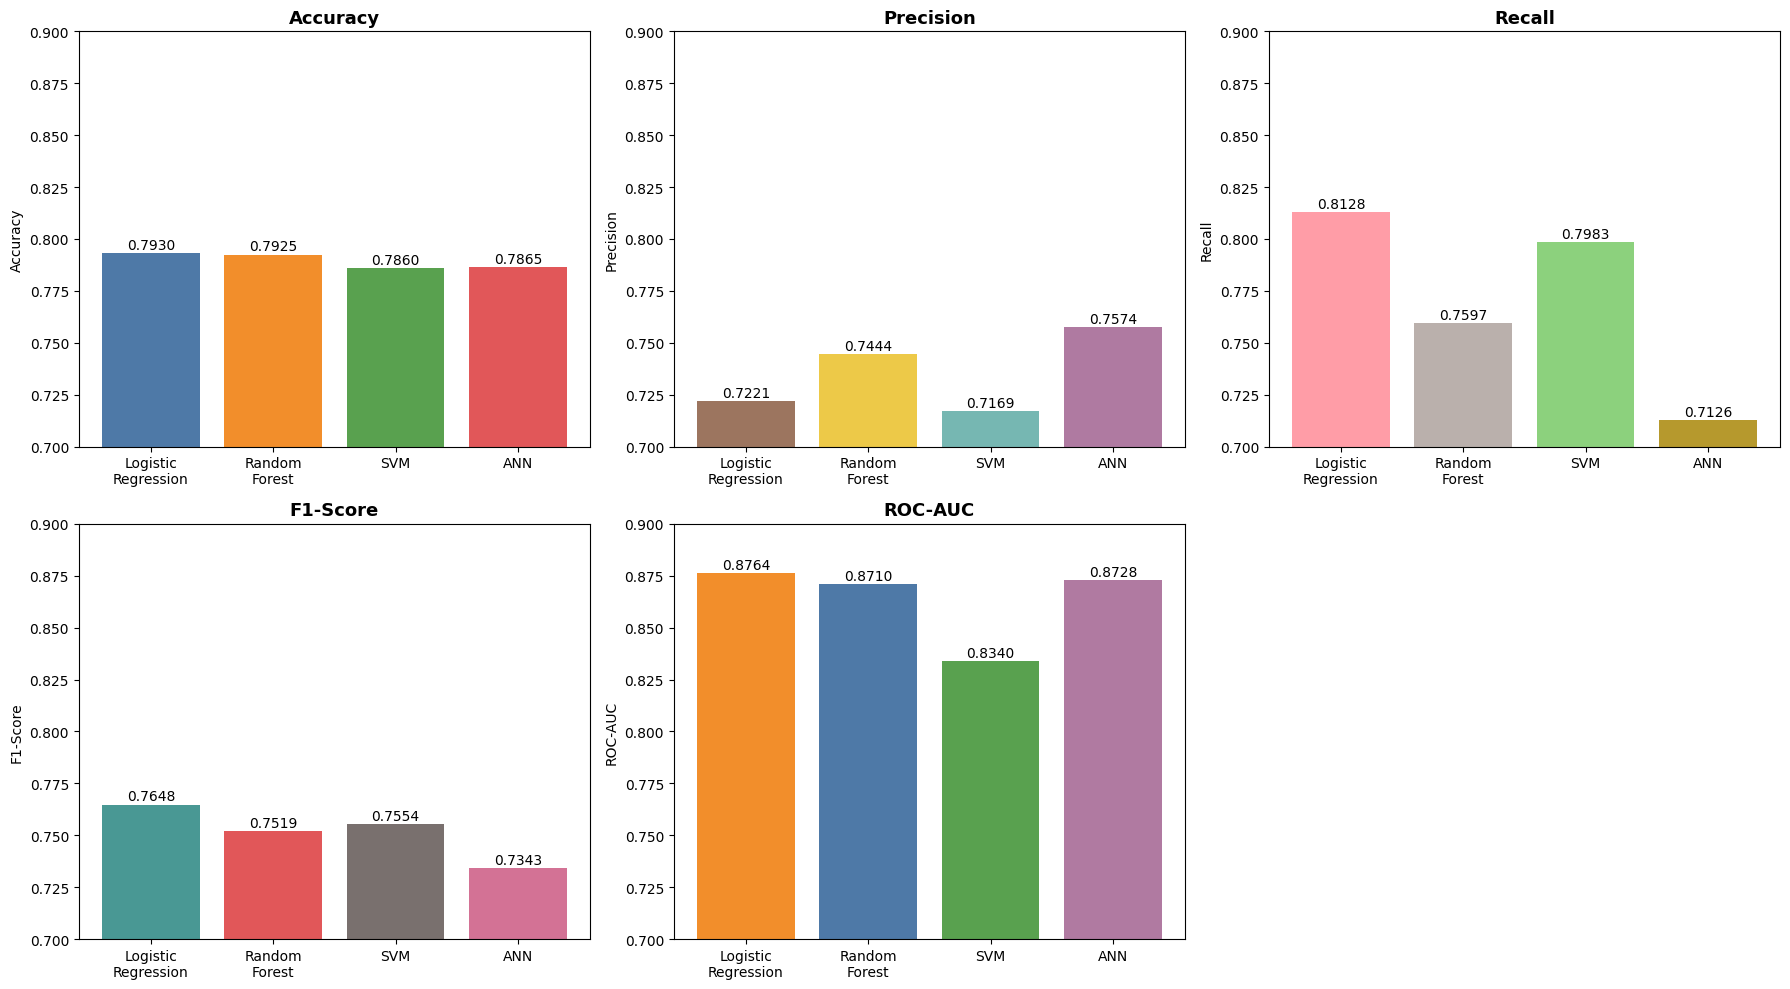

In [42]:
# I imported the required libraries.
import matplotlib.pyplot as plt

# I prepared the data.
models = [
    "Logistic\nRegression",
    "Random\nForest",
    "SVM",
    "ANN"
]

accuracy = [
    tuned_lr_metrics["Accuracy"],
    tuned_rf_metrics["Accuracy"],
    tuned_svm_metrics["Accuracy"],
    tuned_ann_metrics["Accuracy"]
]

precision = [
    tuned_lr_metrics["Precision"],
    tuned_rf_metrics["Precision"],
    tuned_svm_metrics["Precision"],
    tuned_ann_metrics["Precision"]
]

recall = [
    tuned_lr_metrics["Recall"],
    tuned_rf_metrics["Recall"],
    tuned_svm_metrics["Recall"],
    tuned_ann_metrics["Recall"]
]

f1 = [
    tuned_lr_metrics["F1-Score"],
    tuned_rf_metrics["F1-Score"],
    tuned_svm_metrics["F1-Score"],
    tuned_ann_metrics["F1-Score"]
]

roc_auc = [
    tuned_lr_metrics["ROC-AUC"],
    tuned_rf_metrics["ROC-AUC"],
    tuned_svm_metrics["ROC-AUC"],
    tuned_ann_metrics["ROC-AUC"]
]

plt.figure(figsize=(18,10))

# Accuracy
plt.subplot(2,3,1)
bars = plt.bar(models, accuracy, color=["#4E79A7","#F28E2B","#59A14F","#E15759"])
plt.title("Accuracy", fontsize=13, fontweight="bold")
plt.ylabel("Accuracy")
plt.ylim(0.70,0.90)
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+0.002,
             f"{bar.get_height():.4f}",
             ha="center",
             fontsize=10)

# Precision
plt.subplot(2,3,2)
bars = plt.bar(models, precision, color=["#9C755F","#EDC948","#76B7B2","#AF7AA1"])
plt.title("Precision", fontsize=13, fontweight="bold")
plt.ylabel("Precision")
plt.ylim(0.70,0.90)
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+0.002,
             f"{bar.get_height():.4f}",
             ha="center",
             fontsize=10)

# Recall
plt.subplot(2,3,3)
bars = plt.bar(models, recall, color=["#FF9DA7","#BAB0AC","#8CD17D","#B6992D"])
plt.title("Recall", fontsize=13, fontweight="bold")
plt.ylabel("Recall")
plt.ylim(0.70,0.90)
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+0.002,
             f"{bar.get_height():.4f}",
             ha="center",
             fontsize=10)

# F1-Score
plt.subplot(2,3,4)
bars = plt.bar(models, f1, color=["#499894","#E15759","#79706E","#D37295"])
plt.title("F1-Score", fontsize=13, fontweight="bold")
plt.ylabel("F1-Score")
plt.ylim(0.70,.90)
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+0.002,
             f"{bar.get_height():.4f}",
             ha="center",
             fontsize=10)

# ROC-AUC
plt.subplot(2,3,5)
bars = plt.bar(models, roc_auc, color=["#F28E2B","#4E79A7","#59A14F","#B07AA1"])
plt.title("ROC-AUC", fontsize=13, fontweight="bold")
plt.ylabel("ROC-AUC")
plt.ylim(0.70,0.90)
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+0.002,
             f"{bar.get_height():.4f}",
             ha="center",
             fontsize=10)

# Hide the empty subplot
plt.subplot(2,3,6)
plt.axis("off")

plt.tight_layout()
plt.show()

#  Comparative F1-Score for all Tuned Models 

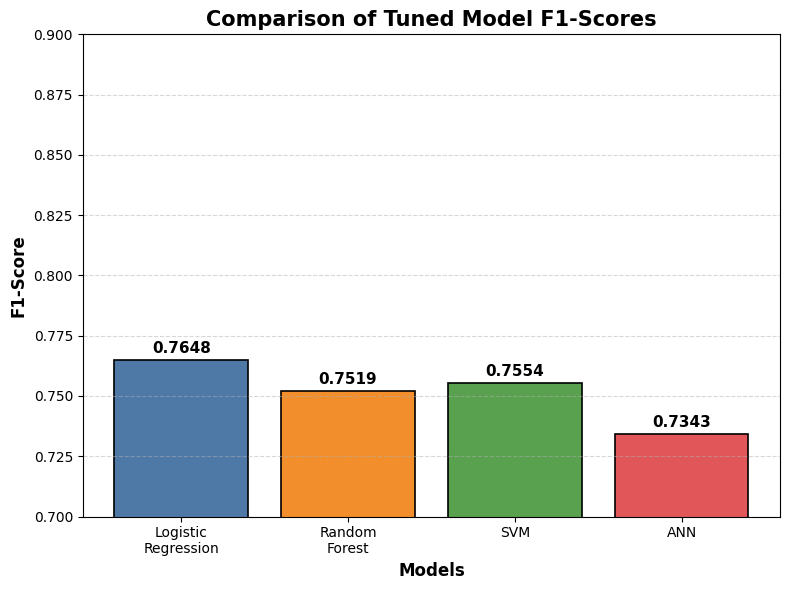

In [43]:
# I imported the required libraries.
import matplotlib.pyplot as plt

# I prepared the data.
models = [
    "Logistic\nRegression",
    "Random\nForest",
    "SVM",
    "ANN"
]

f1_scores = [
    tuned_lr_metrics["F1-Score"],
    tuned_rf_metrics["F1-Score"],
    tuned_svm_metrics["F1-Score"],
    tuned_ann_metrics["F1-Score"]
]

# I created the figure.
plt.figure(figsize=(8,6))

bars = plt.bar(
    models,
    f1_scores,
    color=["#4E79A7", "#F28E2B", "#59A14F", "#E15759"],
    edgecolor="black",
    linewidth=1.2
)

# I added the values on the bars.
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.003,
        f"{bar.get_height():.4f}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

# I formatted the graph.
plt.title(
    "Comparison of Tuned Model F1-Scores",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Models",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "F1-Score",
    fontsize=12,
    fontweight="bold"
)

plt.ylim(0.70, 0.90)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# Combined Comparative Bar Graph for all Tuned Models 

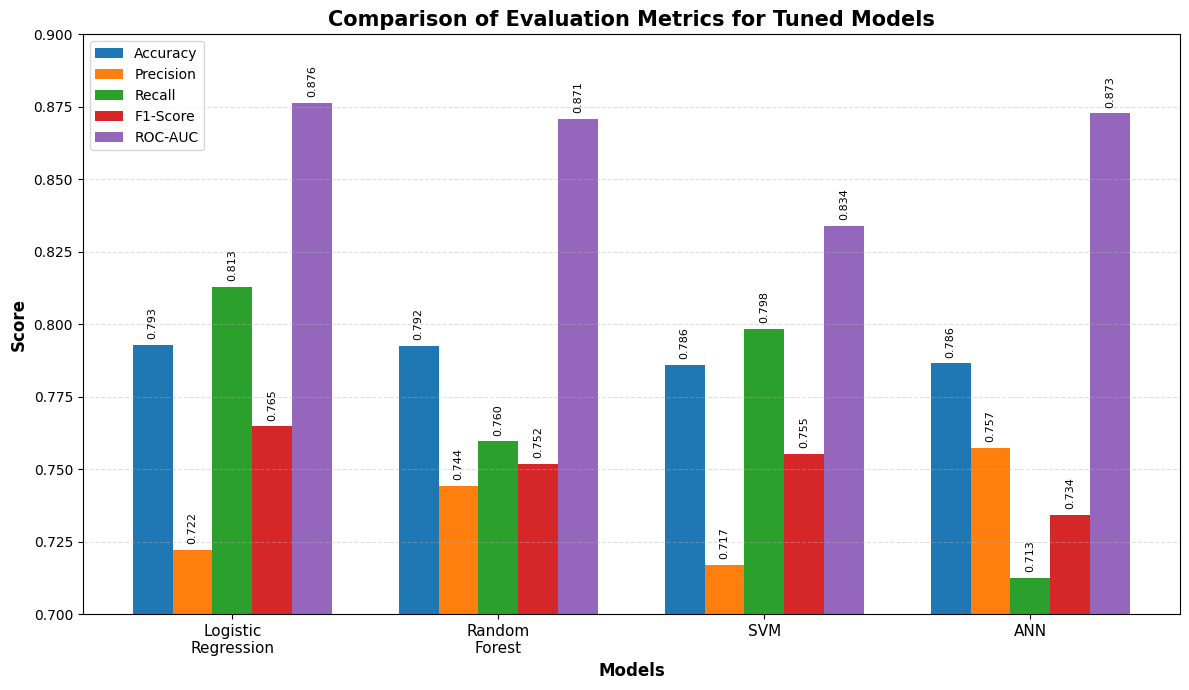

In [44]:
# I imported the required libraries.
import matplotlib.pyplot as plt
import numpy as np

# I prepared the data.
models = [
    "Logistic\nRegression",
    "Random\nForest",
    "SVM",
    "ANN"
]

accuracy = [
    tuned_lr_metrics["Accuracy"],
    tuned_rf_metrics["Accuracy"],
    tuned_svm_metrics["Accuracy"],
    tuned_ann_metrics["Accuracy"]
]

precision = [
    tuned_lr_metrics["Precision"],
    tuned_rf_metrics["Precision"],
    tuned_svm_metrics["Precision"],
    tuned_ann_metrics["Precision"]
]

recall = [
    tuned_lr_metrics["Recall"],
    tuned_rf_metrics["Recall"],
    tuned_svm_metrics["Recall"],
    tuned_ann_metrics["Recall"]
]

f1_score = [
    tuned_lr_metrics["F1-Score"],
    tuned_rf_metrics["F1-Score"],
    tuned_svm_metrics["F1-Score"],
    tuned_ann_metrics["F1-Score"]
]

roc_auc = [
    tuned_lr_metrics["ROC-AUC"],
    tuned_rf_metrics["ROC-AUC"],
    tuned_svm_metrics["ROC-AUC"],
    tuned_ann_metrics["ROC-AUC"]
]

# I created the grouped bar chart.
x = np.arange(len(models))
width = 0.15

plt.figure(figsize=(12,7))

bars1 = plt.bar(x - 2*width, accuracy, width, label="Accuracy")
bars2 = plt.bar(x - width, precision, width, label="Precision")
bars3 = plt.bar(x, recall, width, label="Recall")
bars4 = plt.bar(x + width, f1_score, width, label="F1-Score")
bars5 = plt.bar(x + 2*width, roc_auc, width, label="ROC-AUC")

# I displayed the values on each bar.
for bars in [bars1, bars2, bars3, bars4, bars5]:
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.002,
            f"{bar.get_height():.3f}",
            ha="center",
            va="bottom",
            fontsize=8,
            rotation=90
        )

# I formatted the graph.
plt.title(
    "Comparison of Evaluation Metrics for Tuned Models",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Models",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Score",
    fontsize=12,
    fontweight="bold"
)

plt.xticks(x, models, fontsize=11)
plt.ylim(0.70, 0.90)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.legend(
    loc="upper left",
    fontsize=10
)

plt.tight_layout()
plt.show()

# Combined ROC-AUC Curve for all Tuned Models 

63/63 [==============================] - 0s 4ms/step


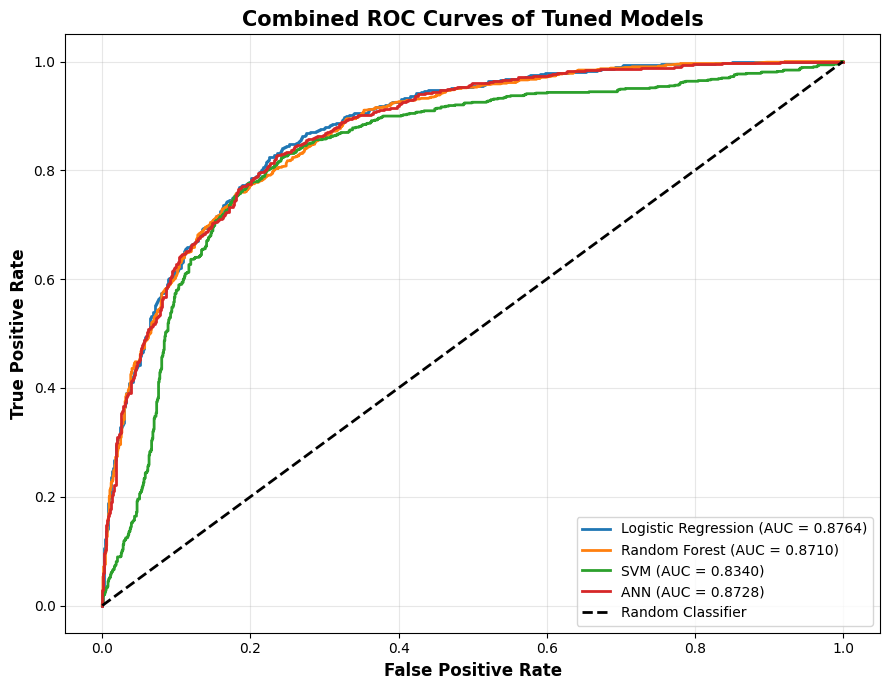

In [46]:
# I imported the required libraries.
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Logistic Regression
lr_prob = lr_grid.best_estimator_.predict_proba(X_test)[:, 1]
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
lr_auc = roc_auc_score(y_test, lr_prob)

# Random Forest
rf_prob = rf_grid.best_estimator_.predict_proba(X_test)[:, 1]
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
rf_auc = roc_auc_score(y_test, rf_prob)

# Support Vector Machine
svm_prob = svm_grid.best_estimator_.predict_proba(X_test)[:, 1]
svm_fpr, svm_tpr, _ = roc_curve(y_test, svm_prob)
svm_auc = roc_auc_score(y_test, svm_prob)

# Artificial Neural Network
ann_prob = ann_model.predict(X_test).ravel()
ann_fpr, ann_tpr, _ = roc_curve(y_test, ann_prob)
ann_auc = roc_auc_score(y_test, ann_prob)

# I plotted the ROC curves.
plt.figure(figsize=(9,7))

plt.plot(lr_fpr, lr_tpr, linewidth=2,
         label=f"Logistic Regression (AUC = {lr_auc:.4f})")

plt.plot(rf_fpr, rf_tpr, linewidth=2,
         label=f"Random Forest (AUC = {rf_auc:.4f})")

plt.plot(svm_fpr, svm_tpr, linewidth=2,
         label=f"SVM (AUC = {svm_auc:.4f})")

plt.plot(ann_fpr, ann_tpr, linewidth=2,
         label=f"ANN (AUC = {ann_auc:.4f})")

# Random classifier
plt.plot([0,1], [0,1],
         linestyle="--",
         color="black",
         linewidth=2,
         label="Random Classifier")

plt.title(
    "Combined ROC Curves of Tuned Models",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "False Positive Rate",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "True Positive Rate",
    fontsize=12,
    fontweight="bold"
)

plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Combined Comparative Table for all Baseline and Tuned Models 

In [47]:
# I imported the required libraries.
import pandas as pd
from IPython.display import display

# I created the comparative performance table.
comparison_table = pd.DataFrame({

    "Model": [

        "Logistic Regression (Baseline)",
        "Logistic Regression (Tuned)",

        "Random Forest (Baseline)",
        "Random Forest (Tuned)",

        "Support Vector Machine (Baseline)",
        "Support Vector Machine (Tuned)",

        "Artificial Neural Network (Baseline)",
        "Artificial Neural Network (Tuned)"
    ],

    "Accuracy": [

        baseline_lr_metrics["Accuracy"],
        tuned_lr_metrics["Accuracy"],

        baseline_rf_metrics["Accuracy"],
        tuned_rf_metrics["Accuracy"],

        baseline_svm_metrics["Accuracy"],
        tuned_svm_metrics["Accuracy"],

        baseline_ann_metrics["Accuracy"],
        tuned_ann_metrics["Accuracy"]
    ],

    "Precision": [

        baseline_lr_metrics["Precision"],
        tuned_lr_metrics["Precision"],

        baseline_rf_metrics["Precision"],
        tuned_rf_metrics["Precision"],

        baseline_svm_metrics["Precision"],
        tuned_svm_metrics["Precision"],

        baseline_ann_metrics["Precision"],
        tuned_ann_metrics["Precision"]
    ],

    "Recall": [

        baseline_lr_metrics["Recall"],
        tuned_lr_metrics["Recall"],

        baseline_rf_metrics["Recall"],
        tuned_rf_metrics["Recall"],

        baseline_svm_metrics["Recall"],
        tuned_svm_metrics["Recall"],

        baseline_ann_metrics["Recall"],
        tuned_ann_metrics["Recall"]
    ],

    "F1-Score": [

        baseline_lr_metrics["F1-Score"],
        tuned_lr_metrics["F1-Score"],

        baseline_rf_metrics["F1-Score"],
        tuned_rf_metrics["F1-Score"],

        baseline_svm_metrics["F1-Score"],
        tuned_svm_metrics["F1-Score"],

        baseline_ann_metrics["F1-Score"],
        tuned_ann_metrics["F1-Score"]
    ],

    "ROC-AUC": [

        baseline_lr_metrics["ROC-AUC"],
        tuned_lr_metrics["ROC-AUC"],

        baseline_rf_metrics["ROC-AUC"],
        tuned_rf_metrics["ROC-AUC"],

        baseline_svm_metrics["ROC-AUC"],
        tuned_svm_metrics["ROC-AUC"],

        baseline_ann_metrics["ROC-AUC"],
        tuned_ann_metrics["ROC-AUC"]
    ]
})

# I rounded the numerical values.
metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]

comparison_table[metric_columns] = comparison_table[metric_columns].round(4)

# I styled the table.
styled_table = (

    comparison_table.style

    .highlight_max(
        subset=metric_columns,
        color="#FFF2CC"
    )

    .set_properties(
        subset=["Model"],
        **{
            "font-weight": "bold",
            "background-color": "#F2F2F2",
            "border": "1px solid black"
        }
    )

    .set_properties(
        subset=metric_columns,
        **{
            "text-align": "center",
            "border": "1px solid black"
        }
    )

    .set_table_styles([

        {
            "selector": "th",
            "props": [
                ("background-color", "#1F4E78"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("border", "1px solid black")
            ]
        },

        {
            "selector": "td",
            "props": [
                ("padding", "8px")
            ]
        }

    ])

    .format("{:.4f}", subset=metric_columns)

)

display(styled_table)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression (Baseline),0.7930,0.7221,0.8128,0.7648,0.8764
1,Logistic Regression (Tuned),0.7930,0.7221,0.8128,0.7648,0.8764
2,Random Forest (Baseline),0.7860,0.7353,0.7548,0.7449,0.8673
3,Random Forest (Tuned),0.7925,0.7444,0.7597,0.7519,0.8710
4,Support Vector Machine (Baseline),0.7905,0.7240,0.7983,0.7593,0.8462
5,Support Vector Machine (Tuned),0.7860,0.7169,0.7983,0.7554,0.8340
6,Artificial Neural Network (Baseline),0.7930,0.7614,0.7283,0.7444,0.8739
7,Artificial Neural Network (Tuned),0.7865,0.7574,0.7126,0.7343,0.8728


# Visual Analysis for Each Metric : Baseline and Tuned Models 

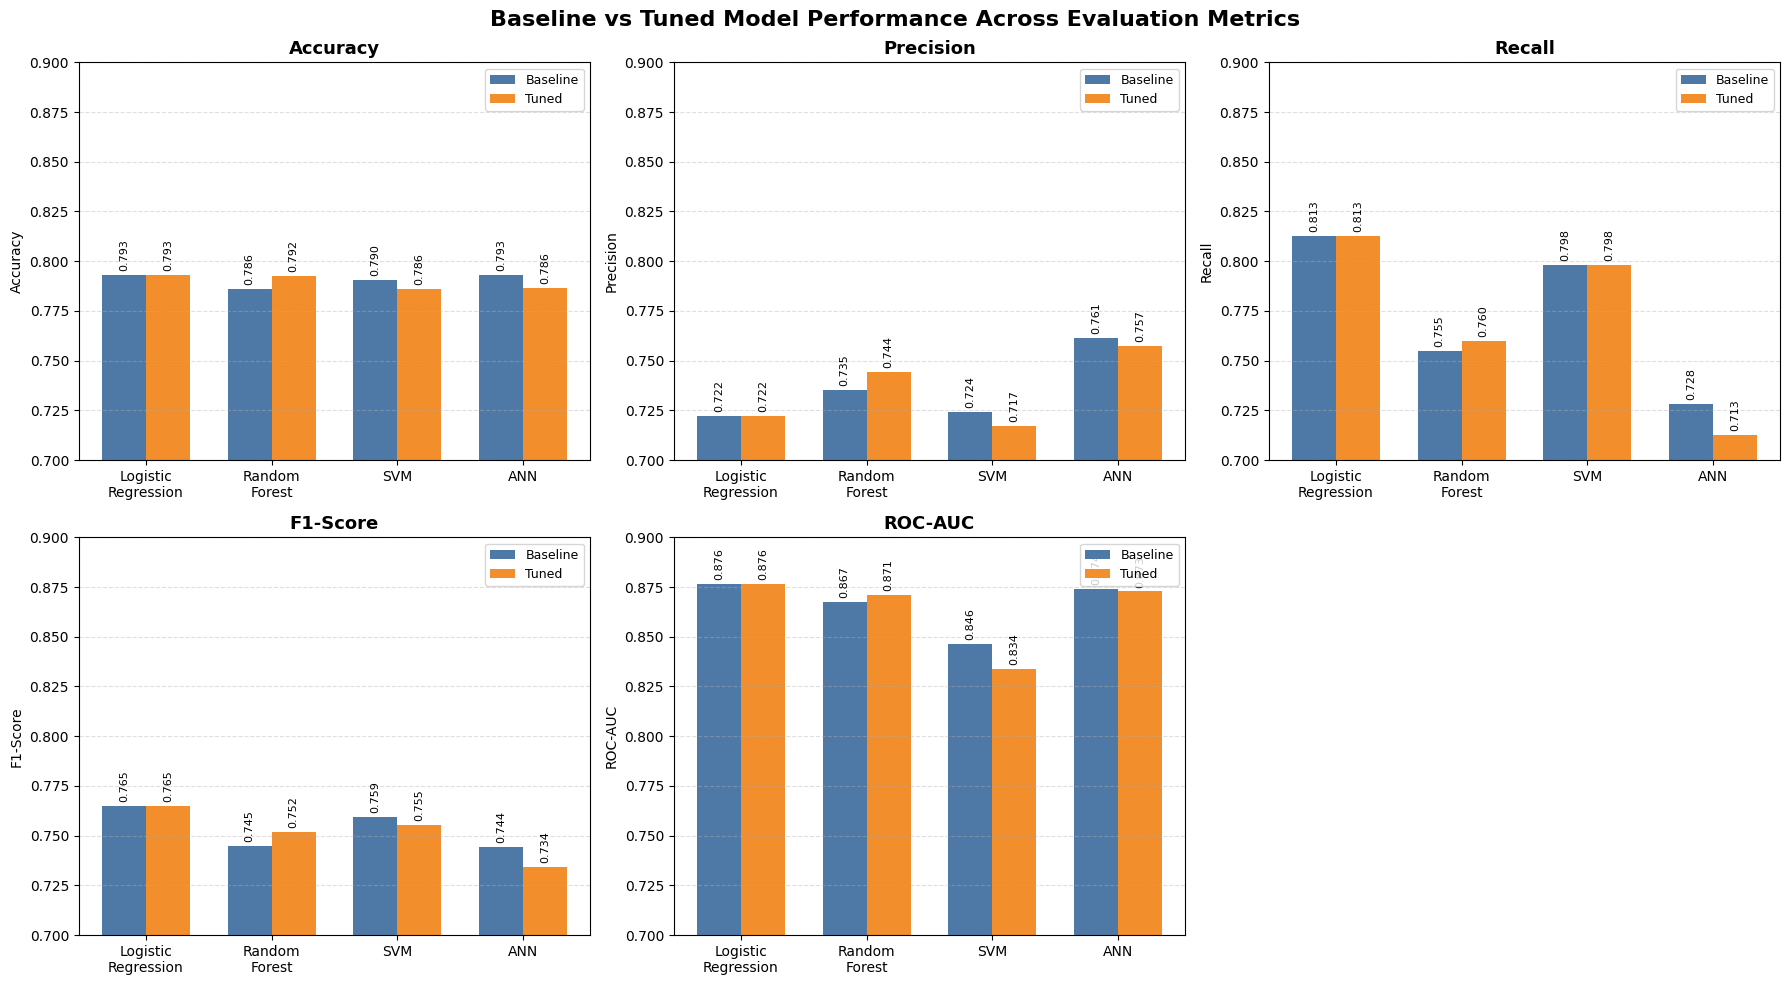

In [49]:
# I imported the required libraries.
import matplotlib.pyplot as plt
import numpy as np

# I prepared the data.
models = [
    "Logistic\nRegression",
    "Random\nForest",
    "SVM",
    "ANN"
]

metrics = {
    "Accuracy": (
        [
            baseline_lr_metrics["Accuracy"],
            baseline_rf_metrics["Accuracy"],
            baseline_svm_metrics["Accuracy"],
            baseline_ann_metrics["Accuracy"]
        ],
        [
            tuned_lr_metrics["Accuracy"],
            tuned_rf_metrics["Accuracy"],
            tuned_svm_metrics["Accuracy"],
            tuned_ann_metrics["Accuracy"]
        ]
    ),

    "Precision": (
        [
            baseline_lr_metrics["Precision"],
            baseline_rf_metrics["Precision"],
            baseline_svm_metrics["Precision"],
            baseline_ann_metrics["Precision"]
        ],
        [
            tuned_lr_metrics["Precision"],
            tuned_rf_metrics["Precision"],
            tuned_svm_metrics["Precision"],
            tuned_ann_metrics["Precision"]
        ]
    ),

    "Recall": (
        [
            baseline_lr_metrics["Recall"],
            baseline_rf_metrics["Recall"],
            baseline_svm_metrics["Recall"],
            baseline_ann_metrics["Recall"]
        ],
        [
            tuned_lr_metrics["Recall"],
            tuned_rf_metrics["Recall"],
            tuned_svm_metrics["Recall"],
            tuned_ann_metrics["Recall"]
        ]
    ),

    "F1-Score": (
        [
            baseline_lr_metrics["F1-Score"],
            baseline_rf_metrics["F1-Score"],
            baseline_svm_metrics["F1-Score"],
            baseline_ann_metrics["F1-Score"]
        ],
        [
            tuned_lr_metrics["F1-Score"],
            tuned_rf_metrics["F1-Score"],
            tuned_svm_metrics["F1-Score"],
            tuned_ann_metrics["F1-Score"]
        ]
    ),

    "ROC-AUC": (
        [
            baseline_lr_metrics["ROC-AUC"],
            baseline_rf_metrics["ROC-AUC"],
            baseline_svm_metrics["ROC-AUC"],
            baseline_ann_metrics["ROC-AUC"]
        ],
        [
            tuned_lr_metrics["ROC-AUC"],
            tuned_rf_metrics["ROC-AUC"],
            tuned_svm_metrics["ROC-AUC"],
            tuned_ann_metrics["ROC-AUC"]
        ]
    )
}

# I created the graphs.
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

width = 0.35
x = np.arange(len(models))

colors = ["#4E79A7", "#F28E2B"]

for ax, (metric, (baseline, tuned)) in zip(axes.flat, metrics.items()):

    bars1 = ax.bar(x - width/2, baseline, width,
                   label="Baseline",
                   color=colors[0])

    bars2 = ax.bar(x + width/2, tuned, width,
                   label="Tuned",
                   color=colors[1])

    ax.set_title(metric, fontsize=13, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.set_ylabel(metric)
    ax.set_ylim(0.70, 0.90)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    for bars in [bars1, bars2]:
        for bar in bars:
            ax.text(
                bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.003,
                f"{bar.get_height():.3f}",
                ha="center",
                fontsize=8,
                rotation=90
            )

    ax.legend(fontsize=9)

# Hide the unused subplot.
axes[1,2].axis("off")

plt.suptitle(
    "Baseline vs Tuned Model Performance Across Evaluation Metrics",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# Combined Comparative Bar Graph for all Baseline and Tuned Models 

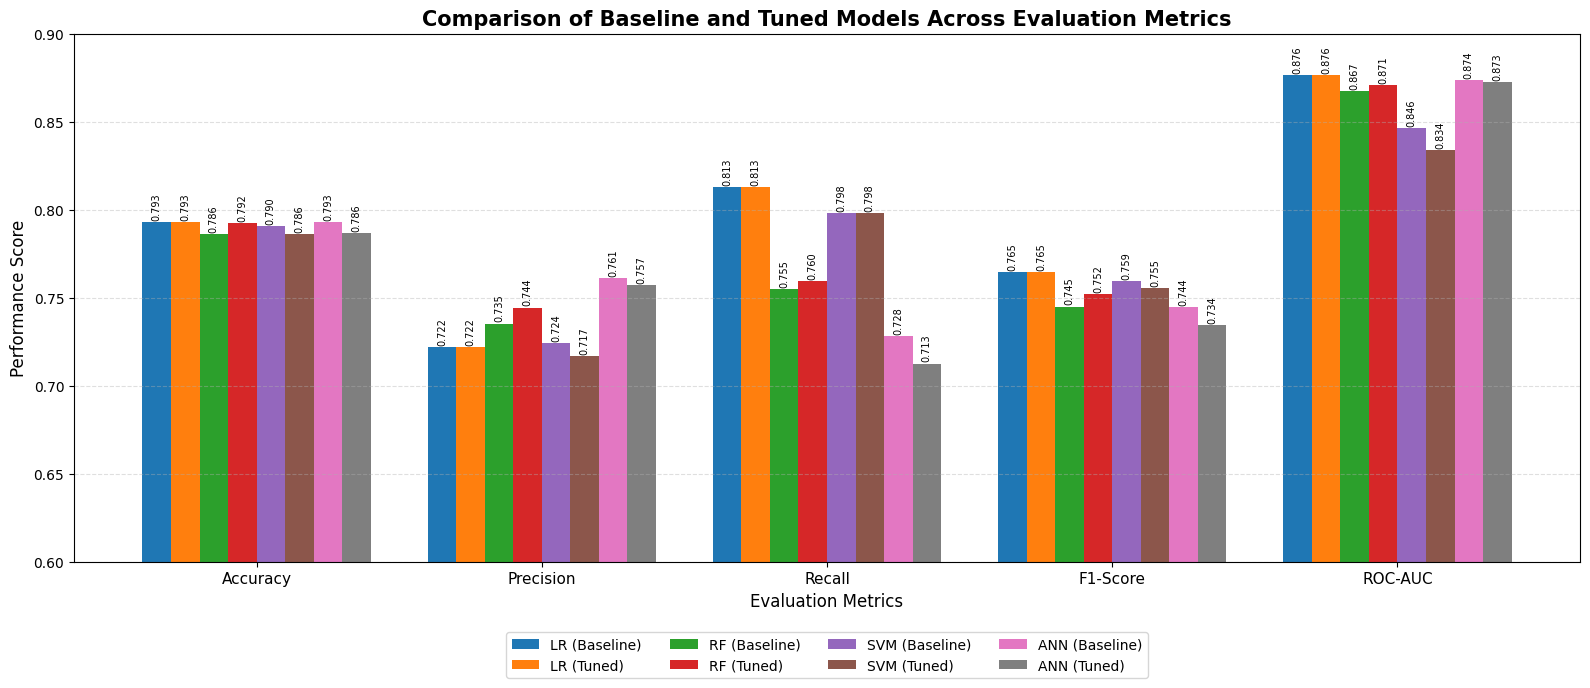

In [55]:
# I imported the required libraries.
import matplotlib.pyplot as plt
import numpy as np

# Metrics.
metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]

# Performance values.
lr_base = [
    baseline_lr_metrics["Accuracy"],
    baseline_lr_metrics["Precision"],
    baseline_lr_metrics["Recall"],
    baseline_lr_metrics["F1-Score"],
    baseline_lr_metrics["ROC-AUC"]
]

lr_tuned = [
    tuned_lr_metrics["Accuracy"],
    tuned_lr_metrics["Precision"],
    tuned_lr_metrics["Recall"],
    tuned_lr_metrics["F1-Score"],
    tuned_lr_metrics["ROC-AUC"]
]

rf_base = [
    baseline_rf_metrics["Accuracy"],
    baseline_rf_metrics["Precision"],
    baseline_rf_metrics["Recall"],
    baseline_rf_metrics["F1-Score"],
    baseline_rf_metrics["ROC-AUC"]
]

rf_tuned = [
    tuned_rf_metrics["Accuracy"],
    tuned_rf_metrics["Precision"],
    tuned_rf_metrics["Recall"],
    tuned_rf_metrics["F1-Score"],
    tuned_rf_metrics["ROC-AUC"]
]

svm_base = [
    baseline_svm_metrics["Accuracy"],
    baseline_svm_metrics["Precision"],
    baseline_svm_metrics["Recall"],
    baseline_svm_metrics["F1-Score"],
    baseline_svm_metrics["ROC-AUC"]
]

svm_tuned = [
    tuned_svm_metrics["Accuracy"],
    tuned_svm_metrics["Precision"],
    tuned_svm_metrics["Recall"],
    tuned_svm_metrics["F1-Score"],
    tuned_svm_metrics["ROC-AUC"]
]

ann_base = [
    baseline_ann_metrics["Accuracy"],
    baseline_ann_metrics["Precision"],
    baseline_ann_metrics["Recall"],
    baseline_ann_metrics["F1-Score"],
    baseline_ann_metrics["ROC-AUC"]
]

ann_tuned = [
    tuned_ann_metrics["Accuracy"],
    tuned_ann_metrics["Precision"],
    tuned_ann_metrics["Recall"],
    tuned_ann_metrics["F1-Score"],
    tuned_ann_metrics["ROC-AUC"]
]

x = np.arange(len(metrics))
width = 0.10

plt.figure(figsize=(16,7))

bars1 = plt.bar(x-3.5*width, lr_base, width, label="LR (Baseline)")
bars2 = plt.bar(x-2.5*width, lr_tuned, width, label="LR (Tuned)")
bars3 = plt.bar(x-1.5*width, rf_base, width, label="RF (Baseline)")
bars4 = plt.bar(x-0.5*width, rf_tuned, width, label="RF (Tuned)")
bars5 = plt.bar(x+0.5*width, svm_base, width, label="SVM (Baseline)")
bars6 = plt.bar(x+1.5*width, svm_tuned, width, label="SVM (Tuned)")
bars7 = plt.bar(x+2.5*width, ann_base, width, label="ANN (Baseline)")
bars8 = plt.bar(x+3.5*width, ann_tuned, width, label="ANN (Tuned)")

plt.xticks(x, metrics, fontsize=11)
plt.ylabel("Performance Score", fontsize=12)
plt.xlabel("Evaluation Metrics", fontsize=12)

plt.title(
    "Comparison of Baseline and Tuned Models Across Evaluation Metrics",
    fontsize=15,
    fontweight="bold"
)

plt.ylim(0.60,0.90)
plt.grid(axis="y", linestyle="--", alpha=0.4)

# Value labels
for group in [bars1,bars2,bars3,bars4,bars5,bars6,bars7,bars8]:
    for bar in group:
        plt.text(
            bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.001,
            f"{bar.get_height():.3f}",
            ha="center",
            va="bottom",
            fontsize=7,
            rotation=90
        )

plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5,-0.12),
    ncol=4,
    frameon=True
)

plt.tight_layout()
plt.show()

# Combined F1-Score 

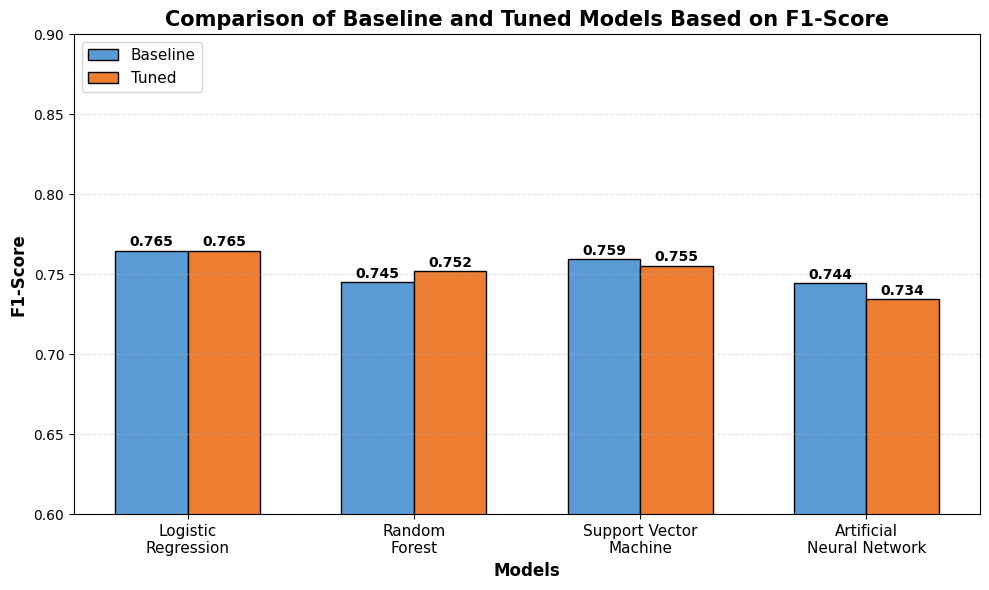

In [59]:
# I imported the required libraries.
import matplotlib.pyplot as plt
import numpy as np

# Model names.
models = [
    "Logistic\nRegression",
    "Random\nForest",
    "Support Vector\nMachine",
    "Artificial\nNeural Network"
]

# F1-Score values.
baseline = [
    baseline_lr_metrics["F1-Score"],
    baseline_rf_metrics["F1-Score"],
    baseline_svm_metrics["F1-Score"],
    baseline_ann_metrics["F1-Score"]
]

tuned = [
    tuned_lr_metrics["F1-Score"],
    tuned_rf_metrics["F1-Score"],
    tuned_svm_metrics["F1-Score"],
    tuned_ann_metrics["F1-Score"]
]

# X-axis positions.
x = np.arange(len(models))
width = 0.32

# Create figure.
plt.figure(figsize=(10,6))

bars1 = plt.bar(
    x - width/2,
    baseline,
    width,
    label="Baseline",
    color="#5B9BD5",
    edgecolor="black",
    linewidth=1
)

bars2 = plt.bar(
    x + width/2,
    tuned,
    width,
    label="Tuned",
    color="#ED7D31",
    edgecolor="black",
    linewidth=1
)

# Value labels.
for bars in [bars1, bars2]:
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.001,
            f"{bar.get_height():.3f}",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

# Formatting.
plt.xticks(x, models, fontsize=11)
plt.ylabel("F1-Score", fontsize=12, fontweight="bold")
plt.xlabel("Models", fontsize=12, fontweight="bold")

plt.title(
    "Comparison of Baseline and Tuned Models Based on F1-Score",
    fontsize=15,
    fontweight="bold"
)

# Zoom in to highlight differences.
plt.ylim(0.60, 0.90)

plt.grid(axis="y", linestyle="--", alpha=0.35)

plt.legend(
    fontsize=11,
    frameon=True,
    loc="upper left"
)

plt.tight_layout()
plt.show()

# Best Perfoming Model : Based on all Metrics 

In [69]:
# I imported the required libraries.
import pandas as pd

# I created the comparison table.
comparison_table = pd.DataFrame([

    baseline_lr_metrics,
    tuned_lr_metrics,

    baseline_rf_metrics,
    tuned_rf_metrics,

    baseline_svm_metrics,
    tuned_svm_metrics,

    baseline_ann_metrics,
    tuned_ann_metrics

])

# I calculated the overall performance score.
comparison_table["Overall Score"] = (
    comparison_table["Accuracy"] +
    comparison_table["Precision"] +
    comparison_table["Recall"] +
    comparison_table["F1-Score"] +
    comparison_table["ROC-AUC"]
) / 5

# I sorted the models by the overall score.
comparison_table = comparison_table.sort_values(
    by="Overall Score",
    ascending=False
).reset_index(drop=True)

comparison_table = comparison_table.round(4)

print(comparison_table)

# I selected the best performing model.
best_model = comparison_table.iloc[0]


print("BEST PERFORMING MODEL")

print(f"Model         : {best_model['Model']}")
print(f"Accuracy      : {best_model['Accuracy']:.4f}")
print(f"Precision     : {best_model['Precision']:.4f}")
print(f"Recall        : {best_model['Recall']:.4f}")
print(f"F1-Score      : {best_model['F1-Score']:.4f}")
print(f"ROC-AUC       : {best_model['ROC-AUC']:.4f}")
print(f"Overall Score : {best_model['Overall Score']:.4f}")


                               Model  Accuracy  Precision  Recall  F1-Score  \
0                Logistic Regression    0.7930     0.7221  0.8128    0.7648   
1        Logistic Regression (Tuned)    0.7930     0.7221  0.8128    0.7648   
2              Random Forest (Tuned)    0.7925     0.7444  0.7597    0.7519   
3             Support Vector Machine    0.7905     0.7240  0.7983    0.7593   
4          Artificial Neural Network    0.7930     0.7614  0.7283    0.7444   
5     Support Vector Machine (Tuned)    0.7860     0.7169  0.7983    0.7554   
6                      Random Forest    0.7860     0.7353  0.7548    0.7449   
7  Artificial Neural Network (Tuned)    0.7865     0.7574  0.7126    0.7343   

   ROC-AUC  Cross-Validation Accuracy  Validation Accuracy  Overall Score  
0   0.8764                        NaN                  NaN         0.7938  
1   0.8764                     0.7983                  NaN         0.7938  
2   0.8710                     0.8201                  NaN  

# Best Perfoming Model : Based on F1-Score 

In [68]:
# I imported the required library.
import pandas as pd

# I created the comparison table.
comparison_table = pd.DataFrame([

    baseline_lr_metrics,
    tuned_lr_metrics,

    baseline_rf_metrics,
    tuned_rf_metrics,

    baseline_svm_metrics,
    tuned_svm_metrics,

    baseline_ann_metrics,
    tuned_ann_metrics

])

# I sorted the models based on the F1-Score.
comparison_table = comparison_table.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

comparison_table = comparison_table.round(4)

print(comparison_table)

# I selected the best performing model.
best_model = comparison_table.iloc[0]


print("BEST PERFORMING MODEL BASED ON F1-SCORE")


print(f"Model      : {best_model['Model']}")
print(f"F1-Score   : {best_model['F1-Score']:.4f}")


                               Model  Accuracy  Precision  Recall  F1-Score  \
0                Logistic Regression    0.7930     0.7221  0.8128    0.7648   
1        Logistic Regression (Tuned)    0.7930     0.7221  0.8128    0.7648   
2             Support Vector Machine    0.7905     0.7240  0.7983    0.7593   
3     Support Vector Machine (Tuned)    0.7860     0.7169  0.7983    0.7554   
4              Random Forest (Tuned)    0.7925     0.7444  0.7597    0.7519   
5                      Random Forest    0.7860     0.7353  0.7548    0.7449   
6          Artificial Neural Network    0.7930     0.7614  0.7283    0.7444   
7  Artificial Neural Network (Tuned)    0.7865     0.7574  0.7126    0.7343   

   ROC-AUC  Cross-Validation Accuracy  Validation Accuracy  
0   0.8764                        NaN                  NaN  
1   0.8764                     0.7983                  NaN  
2   0.8462                        NaN                  NaN  
3   0.8340                     0.8019       

# Saving the Best Model 

In [71]:
# I imported the required library.
import joblib

# I saved the best performing Logistic Regression model.
joblib.dump(lr_grid.best_estimator_, "best_logistic_regression_model.pkl")

# I saved the StandardScaler.
joblib.dump(scaler, "standard_scaler.pkl")

# I saved the LabelEncoder.
joblib.dump(label_encoder, "label_encoder.pkl")


['label_encoder.pkl']

# SHAP Analysis 

SHAP analysis completed successfully.


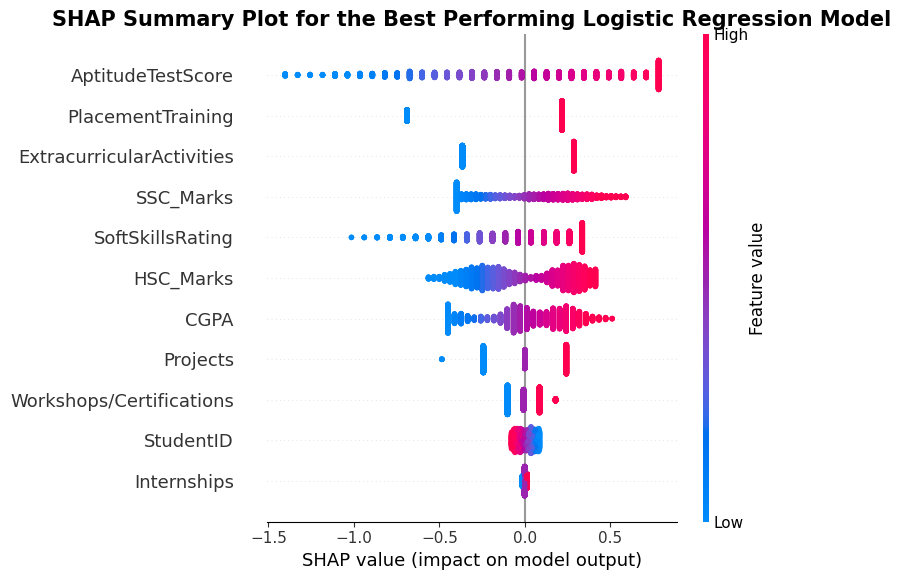

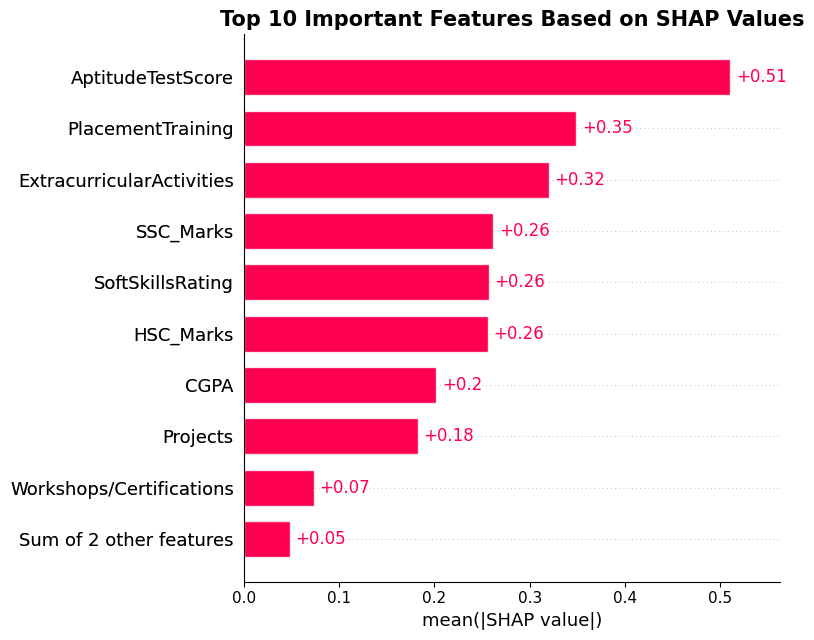

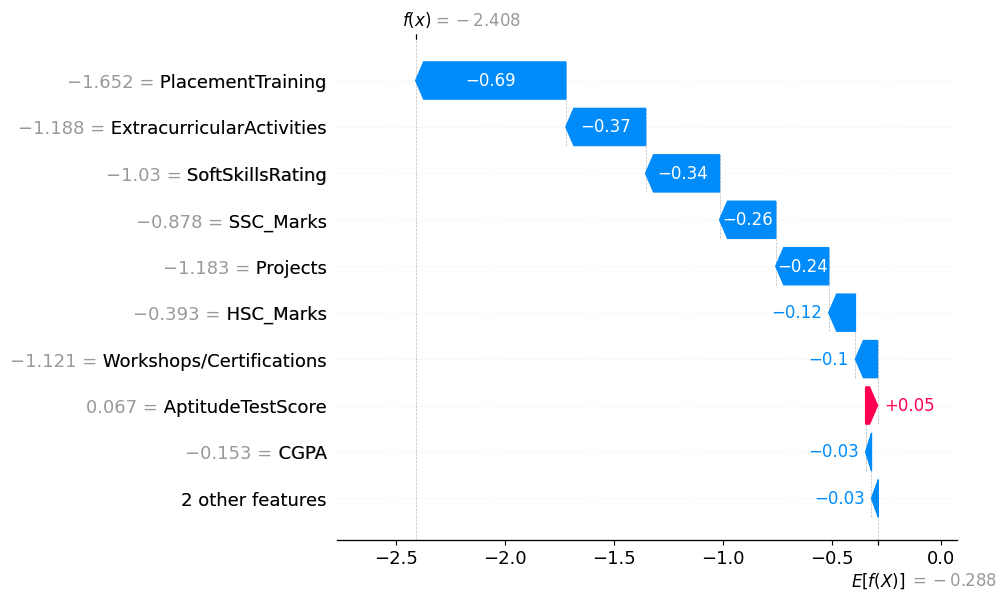

Most Important Feature: AptitudeTestScore


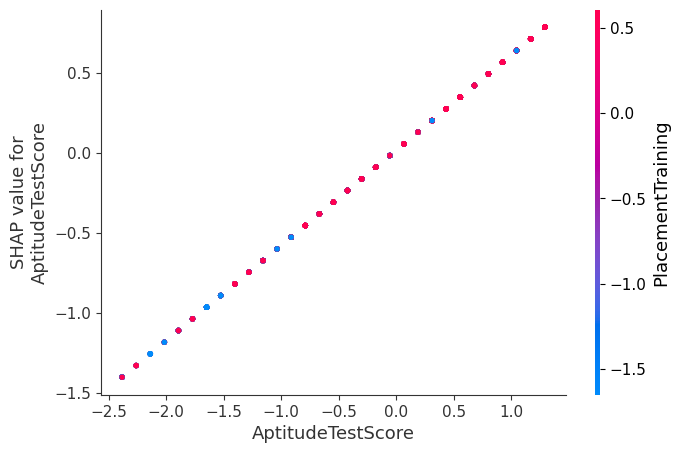

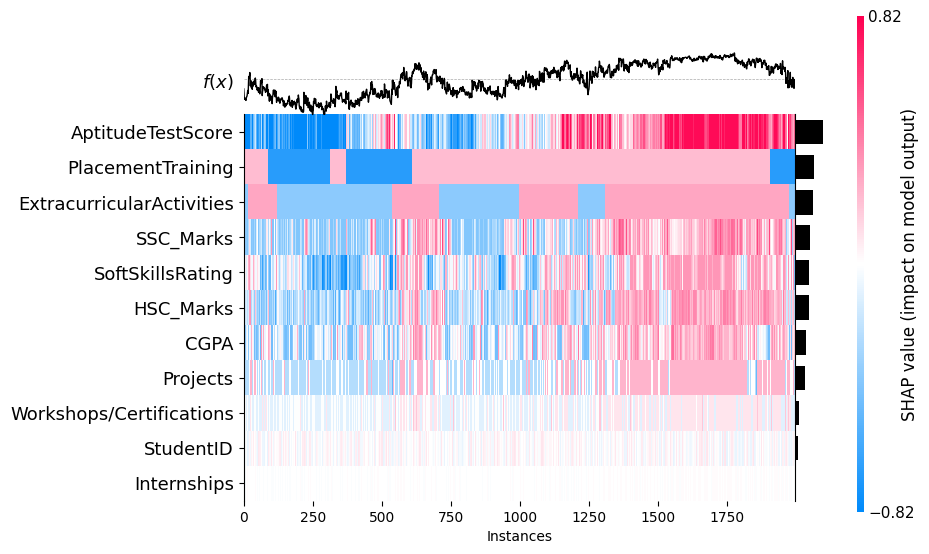


Top 10 Most Important Features
                      Feature  Importance
5           AptitudeTestScore    0.510134
8           PlacementTraining    0.348563
7   ExtracurricularActivities    0.320166
9                   SSC_Marks    0.261860
6            SoftSkillsRating    0.256901
10                  HSC_Marks    0.256234
1                        CGPA    0.201971
3                    Projects    0.182828
4    Workshops/Certifications    0.073503
0                   StudentID    0.041780


In [75]:
# I imported the required libraries.
import shap
import pandas as pd
import matplotlib.pyplot as plt

# I converted the testing data into a DataFrame.
X_test_df = pd.DataFrame(X_test, columns=X.columns)

# I selected the best-performing Logistic Regression model.
best_model = lr_grid.best_estimator_

# I created the SHAP explainer.
explainer = shap.Explainer(best_model, X_test_df)

# I calculated the SHAP values.
shap_values = explainer(X_test_df)

print("SHAP analysis completed successfully.")

# I plotted the SHAP summary plot.
plt.figure(figsize=(10,8))

shap.summary_plot(
    shap_values,
    X_test_df,
    show=False
)

plt.title(
    "SHAP Summary Plot for the Best Performing Logistic Regression Model",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


# I plotted the SHAP feature importance bar plot.
plt.figure(figsize=(10,8))

shap.plots.bar(
    shap_values,
    max_display=10,
    show=False
)

plt.title(
    "Top 10 Important Features Based on SHAP Values",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


# I plotted the SHAP waterfall plot for the first testing sample.
shap.plots.waterfall(
    shap_values[0],
    max_display=10
)


# I identified the most important feature.
importance = pd.DataFrame({
    "Feature": X_test_df.columns,
    "Importance": abs(shap_values.values).mean(axis=0)
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

top_feature = importance.iloc[0]["Feature"]

print("Most Important Feature:", top_feature)


# I plotted the SHAP dependence plot for the most important feature.
shap.dependence_plot(
    top_feature,
    shap_values.values,
    X_test_df,
    interaction_index="auto"
)


# I plotted the SHAP heatmap.
shap.plots.heatmap(
    shap_values,
    max_display=15
)


# I displayed the top 10 most important features.
top_features = importance.head(10)

print("\nTop 10 Most Important Features")
print(top_features)

# Building User Interface For Model Evaluation Purpose

# It is built to predict placement though various features by passing inputs

In [84]:
!pip install openpyxl

In [95]:
import tkinter as tk
from tkinter import ttk, messagebox
from tkinter.scrolledtext import ScrolledText

import pandas as pd
import numpy as np
import joblib
import os

from datetime import datetime


# Load Saved Model


try:
    model = joblib.load("best_logistic_regression_model.pkl")
    scaler = joblib.load("standard_scaler.pkl")
except:
    messagebox.showerror(
        "Error",
        "Cannot find best_logistic_regression_model.pkl or standard_scaler.pkl"
    )
    raise



root = tk.Tk()

root.title("Student Placement Prediction Prototype")
root.geometry("1400x850")
root.configure(bg="#EEF5FF")
root.state("zoomed")



TITLE_FONT = ("Segoe UI", 22, "bold")
HEADER_FONT = ("Segoe UI", 15, "bold")
LABEL_FONT = ("Segoe UI", 11)
BUTTON_FONT = ("Segoe UI", 11, "bold")
RESULT_FONT = ("Segoe UI", 18, "bold")


PRIMARY = "#1565C0"
SECONDARY = "#1976D2"
BACKGROUND = "#EEF5FF"
CARD = "white"
SUCCESS = "#2E7D32"
WARNING = "#EF6C00"
DANGER = "#C62828"



student_id = tk.StringVar()

cgpa = tk.StringVar()

internships = tk.StringVar()

projects = tk.StringVar()

workshops = tk.StringVar()

aptitude = tk.StringVar()

softskills = tk.StringVar()

extracurricular = tk.StringVar(value="No")

placementtraining = tk.StringVar(value="No")

ssc = tk.StringVar()

hsc = tk.StringVar()

prediction = tk.StringVar()

confidence = tk.StringVar()

# Human Evaluation

ease_use = tk.StringVar(value="5")

design = tk.StringVar(value="5")

speed = tk.StringVar(value="5")

accuracy = tk.StringVar(value="5")

recommend = tk.StringVar(value="Yes")



header = tk.Frame(root, bg=PRIMARY, height=80)

header.pack(fill="x")

title = tk.Label(
    header,
    text="Student Placement Prediction and Career Recommendation Prototype",
    bg=PRIMARY,
    fg="white",
    font=TITLE_FONT
)

title.pack(pady=18)



main_frame = tk.Frame(root, bg=BACKGROUND)

main_frame.pack(fill="both", expand=True)

left_frame = tk.Frame(
    main_frame,
    bg=CARD,
    relief="ridge",
    bd=2
)

left_frame.pack(
    side="left",
    fill="both",
    expand=True,
    padx=20,
    pady=20
)

right_frame = tk.Frame(
    main_frame,
    bg=CARD,
    relief="ridge",
    bd=2,
    width=420
)

right_frame.pack(
    side="right",
    fill="y",
    padx=20,
    pady=20
)


student_title = tk.Label(
    left_frame,
    text="Student Academic Information",
    bg="white",
    fg=PRIMARY,
    font=HEADER_FONT
)

student_title.grid(
    row=0,
    column=0,
    columnspan=4,
    pady=20
)



tk.Label(
    left_frame,
    text="Student ID",
    bg="white",
    font=LABEL_FONT
).grid(row=1,column=0,padx=15,pady=12,sticky="w")

student_entry = ttk.Entry(
    left_frame,
    textvariable=student_id,
    width=25
)

student_entry.grid(row=1,column=1,padx=10)

tk.Label(
    left_frame,
    text="CGPA",
    bg="white",
    font=LABEL_FONT
).grid(row=1,column=2,padx=15,sticky="w")

cgpa_entry = ttk.Entry(
    left_frame,
    textvariable=cgpa,
    width=25
)

cgpa_entry.grid(row=1,column=3,padx=10)



tk.Label(
    left_frame,
    text="Internships",
    bg="white",
    font=LABEL_FONT
).grid(row=2,column=0,padx=15,pady=12,sticky="w")

intern_entry = ttk.Combobox(
    left_frame,
    width=22,
    textvariable=internships,
    state="readonly",
    values=[0,1,2,3,4,5]
)

intern_entry.grid(row=2,column=1)

tk.Label(
    left_frame,
    text="Projects",
    bg="white",
    font=LABEL_FONT
).grid(row=2,column=2,padx=15,sticky="w")

project_entry = ttk.Combobox(
    left_frame,
    width=22,
    textvariable=projects,
    state="readonly",
    values=[0,1,2,3,4,5,6,7,8]
)

project_entry.grid(row=2,column=3)


tk.Label(
    left_frame,
    text="Workshops / Certifications",
    bg="white",
    font=LABEL_FONT
).grid(row=3,column=0,padx=15,pady=12,sticky="w")

workshop_entry = ttk.Combobox(
    left_frame,
    width=22,
    textvariable=workshops,
    state="readonly",
    values=[0,1,2,3,4,5]
)

workshop_entry.grid(row=3,column=1)

tk.Label(
    left_frame,
    text="Aptitude Test Score",
    bg="white",
    font=LABEL_FONT
).grid(row=3,column=2,padx=15,sticky="w")

aptitude_entry = ttk.Entry(
    left_frame,
    textvariable=aptitude,
    width=27
)

aptitude_entry.grid(row=3,column=3)



tk.Label(
    left_frame,
    text="Soft Skills Rating",
    bg="white",
    font=LABEL_FONT
).grid(row=4,column=0,padx=15,pady=12,sticky="w")

soft_entry = ttk.Combobox(
    left_frame,
    width=22,
    textvariable=softskills,
    state="readonly",
    values=[1,2,3,4,5,6,7,8,9,10]
)

soft_entry.grid(row=4,column=1)

tk.Label(
    left_frame,
    text="Extracurricular Activities",
    bg="white",
    font=LABEL_FONT
).grid(row=4,column=2,padx=15,sticky="w")

extra_entry = ttk.Combobox(
    left_frame,
    width=22,
    state="readonly",
    textvariable=extracurricular,
    values=["No","Yes"]
)

extra_entry.grid(row=4,column=3)



tk.Label(
    left_frame,
    text="Placement Training",
    bg="white",
    font=LABEL_FONT
).grid(row=5,column=0,padx=15,pady=12,sticky="w")

training_entry = ttk.Combobox(
    left_frame,
    width=22,
    state="readonly",
    textvariable=placementtraining,
    values=["No","Yes"]
)

training_entry.grid(row=5,column=1)

tk.Label(
    left_frame,
    text="SSC Marks",
    bg="white",
    font=LABEL_FONT
).grid(row=5,column=2,padx=15,sticky="w")

ssc_entry = ttk.Entry(
    left_frame,
    textvariable=ssc,
    width=27
)

ssc_entry.grid(row=5,column=3)



tk.Label(
    left_frame,
    text="HSC Marks",
    bg="white",
    font=LABEL_FONT
).grid(row=6,column=0,padx=15,pady=12,sticky="w")

hsc_entry = ttk.Entry(
    left_frame,
    textvariable=hsc,
    width=27
)

hsc_entry.grid(row=6,column=1)



prediction_title = tk.Label(
    right_frame,
    text="Prediction Results",
    bg="white",
    fg=PRIMARY,
    font=HEADER_FONT
)

prediction_title.pack(pady=10)

tk.Label(
    right_frame,
    text="Placement Status",
    bg="white",
    font=("Segoe UI",12,"bold")
).pack()

prediction_label = tk.Label(
    right_frame,
    textvariable=prediction,
    bg="white",
    fg=SUCCESS,
    font=("Segoe UI",24,"bold")
)

prediction_label.pack(pady=5)

tk.Label(
    right_frame,
    text="Prediction Confidence",
    bg="white",
    font=("Segoe UI",12,"bold")
).pack()

confidence_label = tk.Label(
    right_frame,
    textvariable=confidence,
    bg="white",
    fg=PRIMARY,
    font=("Segoe UI",18,"bold")
)

confidence_label.pack(pady=5)

confidence_bar = ttk.Progressbar(
    right_frame,
    orient="horizontal",
    length=300,
    mode="determinate"
)

confidence_bar.pack(pady=10)

status_message = tk.Label(
    right_frame,
    text="Enter student details and click Predict",
    bg="white",
    fg="gray",
    wraplength=350,
    justify="center",
    font=("Segoe UI",10)
)

status_message.pack(pady=5)



def validate_inputs():

    try:

        float(cgpa.get())

        float(aptitude.get())

        float(ssc.get())

        float(hsc.get())

        int(internships.get())

        int(projects.get())

        int(workshops.get())

        int(softskills.get())

        return True

    except:

        messagebox.showerror(
            "Invalid Input",
            "Please enter valid values in every field."
        )

        return False



def predict_student():

    if not validate_inputs():
        return

    try:

        extra = 1 if extracurricular.get()=="Yes" else 0

        training = 1 if placementtraining.get()=="Yes" else 0

        sample = pd.DataFrame([{

            "StudentID":float(student_id.get()),

            "CGPA":float(cgpa.get()),

            "Internships":int(internships.get()),

            "Projects":int(projects.get()),

            "Workshops/Certifications":int(workshops.get()),

            "AptitudeTestScore":float(aptitude.get()),

            "SoftSkillsRating":int(softskills.get()),

            "ExtracurricularActivities":extra,

            "PlacementTraining":training,

            "SSC_Marks":float(ssc.get()),

            "HSC_Marks":float(hsc.get())

        }])

        scaled = scaler.transform(sample)

        pred = model.predict(scaled)[0]

        prob = model.predict_proba(scaled)[0]

        if pred == 1:

            prediction.set("PLACED")

            prediction_label.configure(fg=SUCCESS)

            score = prob[1]

            status_message.config(
                text="Excellent! This student has a high probability of getting placed.",
                fg=SUCCESS
            )

        else:

            prediction.set("NOT PLACED")

            prediction_label.configure(fg=DANGER)

            score = prob[0]

            status_message.config(
                text="This student currently has a lower placement probability.",
                fg=DANGER
            )

        confidence.set(f"{score*100:.2f}%")

        confidence_bar["value"] = score*100

    except Exception as e:

        messagebox.showerror(
            "Prediction Error",
            str(e)
        )



def clear_form():

    student_id.set("")

    cgpa.set("")

    internships.set("")

    projects.set("")

    workshops.set("")

    aptitude.set("")

    softskills.set("")

    extracurricular.set("No")

    placementtraining.set("No")

    ssc.set("")

    hsc.set("")

    prediction.set("")

    confidence.set("")

    confidence_bar["value"]=0

    status_message.config(
        text="Form cleared.",
        fg="gray"
    )


def exit_app():

    if messagebox.askyesno(
        "Exit",
        "Are you sure you want to exit?"
    ):

        root.destroy()



button_frame = tk.Frame(
    left_frame,
    bg="white"
)

button_frame.grid(
    row=8,
    column=0,
    columnspan=4,
    pady=35
)

predict_button = tk.Button(

    button_frame,

    text="Predict Placement",

    bg=PRIMARY,

    fg="white",

    font=BUTTON_FONT,

    width=18,

    command=predict_student

)

predict_button.grid(row=0,column=0,padx=10)

clear_button = tk.Button(

    button_frame,

    text="Clear",

    bg=WARNING,

    fg="white",

    font=BUTTON_FONT,

    width=15,

    command=clear_form

)

clear_button.grid(row=0,column=1,padx=10)

exit_button = tk.Button(

    button_frame,

    text="Exit",

    bg=DANGER,

    fg="white",

    font=BUTTON_FONT,

    width=15,

    command=exit_app

)

exit_button.grid(row=0,column=2,padx=10)



widgets = [

    student_entry,

    cgpa_entry,

    intern_entry,

    project_entry,

    workshop_entry,

    aptitude_entry,

    soft_entry,

    extra_entry,

    training_entry,

    ssc_entry,

    hsc_entry

]

for i in range(len(widgets)-1):

    widgets[i].bind(
        "<Return>",
        lambda event,n=widgets[i+1]: n.focus_set()
    )

widgets[-1].bind(
    "<Return>",
    lambda event: predict_button.focus_set()
)

student_entry.focus_set()



status_bar = tk.Label(

    root,

    text="Ready",

    bd=1,

    relief="sunken",

    anchor="w",

    bg="#F4F6F6",

    font=("Segoe UI",10)

)

status_bar.pack(
    side="bottom",
    fill="x"
)



evaluation_title = tk.Label(
    right_frame,
    text="Human Evaluation",
    bg="white",
    fg=PRIMARY,
    font=HEADER_FONT
)

evaluation_title.pack(pady=(10,5))

evaluation_frame = tk.Frame(
    right_frame,
    bg="white"
)

evaluation_frame.pack(fill="x", padx=20)


tk.Label(
    evaluation_frame,
    text="Ease of Use",
    bg="white",
    font=LABEL_FONT
).grid(row=0,column=0,sticky="w",pady=5)

ease_combo = ttk.Combobox(
    evaluation_frame,
    textvariable=ease_use,
    state="readonly",
    width=20,
    values=["1","2","3","4","5"]
)

ease_combo.grid(row=0,column=1,padx=10)
ease_combo.current(4)


tk.Label(
    evaluation_frame,
    text="Interface Design",
    bg="white",
    font=LABEL_FONT
).grid(row=1,column=0,sticky="w",pady=5)

design_combo = ttk.Combobox(
    evaluation_frame,
    textvariable=design,
    state="readonly",
    width=20,
    values=["1","2","3","4","5"]
)

design_combo.grid(row=1,column=1,padx=10)
design_combo.current(4)



tk.Label(
    evaluation_frame,
    text="Prediction Speed",
    bg="white",
    font=LABEL_FONT
).grid(row=2,column=0,sticky="w",pady=5)

speed_combo = ttk.Combobox(
    evaluation_frame,
    textvariable=speed,
    state="readonly",
    width=20,
    values=["1","2","3","4","5"]
)

speed_combo.grid(row=2,column=1,padx=10)
speed_combo.current(4)



tk.Label(
    evaluation_frame,
    text="Prediction Satisfaction",
    bg="white",
    font=LABEL_FONT
).grid(row=3,column=0,sticky="w",pady=5)

accuracy_combo = ttk.Combobox(
    evaluation_frame,
    textvariable=accuracy,
    state="readonly",
    width=20,
    values=["1","2","3","4","5"]
)

accuracy_combo.grid(row=3,column=1,padx=10)
accuracy_combo.current(4)


tk.Label(
    evaluation_frame,
    text="Recommend Prototype",
    bg="white",
    font=LABEL_FONT
).grid(row=4,column=0,sticky="w",pady=5)

recommend_combo = ttk.Combobox(
    evaluation_frame,
    textvariable=recommend,
    state="readonly",
    width=20,
    values=["Yes","No"]
)

recommend_combo.grid(row=4,column=1,padx=10)


tk.Label(
    right_frame,
    text="Comments",
    bg="white",
    font=LABEL_FONT
).pack(anchor="w",padx=20,pady=(15,5))

comments_box = ScrolledText(
    right_frame,
    width=40,
    height=3,
    font=("Segoe UI",10)
)

comments_box.pack(padx=20)



def save_feedback():

    if prediction.get()=="":

        messagebox.showwarning(
            "Prediction Required",
            "Please predict the student's placement before submitting feedback."
        )

        return

    feedback = {

        "Timestamp":datetime.now(),

        "StudentID":student_id.get(),

        "Prediction":prediction.get(),

        "Confidence":confidence.get(),

        "EaseOfUse":ease_use.get(),

        "InterfaceDesign":design.get(),

        "PredictionSpeed":speed.get(),

        "PredictionSatisfaction":accuracy.get(),

        "Recommend":recommend.get(),

        "Comments":comments_box.get("1.0","end").strip()

    }

    df = pd.DataFrame([feedback])

    csv_file = "student_feedback.csv"

    excel_file = "student_feedback.xlsx"

    if os.path.exists(csv_file):

        df.to_csv(
            csv_file,
            mode="a",
            header=False,
            index=False
        )

    else:

        df.to_csv(
            csv_file,
            index=False
        )

    try:

        if os.path.exists(excel_file):

            existing = pd.read_excel(excel_file)

            existing = pd.concat(
                [existing,df],
                ignore_index=True
            )

            existing.to_excel(
                excel_file,
                index=False
            )

        else:

            df.to_excel(
                excel_file,
                index=False
            )

    except:

        pass

    messagebox.showinfo(
        "Success",
        "Feedback saved successfully."
    )


# Reset Evaluation

def reset_evaluation():

    ease_use.set("5")

    design.set("5")

    speed.set("5")

    accuracy.set("5")

    recommend.set("Yes")

    comments_box.delete(
        "1.0",
        tk.END
    )


# Feedback Buttons


feedback_frame = tk.Frame(
    right_frame,
    bg="white"
)

feedback_frame.pack(pady=8)

save_button = tk.Button(

    feedback_frame,

    text="Save Feedback",

    bg=SUCCESS,

    fg="white",

    font=BUTTON_FONT,

    width=18,

    command=save_feedback

)

save_button.grid(row=0,column=0,padx=8)

reset_button = tk.Button(

    feedback_frame,

    text="Reset Evaluation",

    bg=WARNING,

    fg="white",

    font=BUTTON_FONT,

    width=18,

    command=reset_evaluation

)

reset_button.grid(row=0,column=1,padx=8)



# Prediction History

history = []


# Update Prediction History

def add_history():

    history.append([

        datetime.now().strftime("%Y-%m-%d %H:%M:%S"),

        student_id.get(),

        prediction.get(),

        confidence.get()

    ])


# Statistics


def show_statistics():

    csv_file = "student_feedback.csv"

    if not os.path.exists(csv_file):

        messagebox.showinfo(
            "Statistics",
            "No feedback has been collected yet."
        )

        return

    df = pd.read_csv(csv_file)

    total = len(df)

    avg_ease = round(df["EaseOfUse"].astype(float).mean(),2)

    avg_design = round(df["InterfaceDesign"].astype(float).mean(),2)

    avg_speed = round(df["PredictionSpeed"].astype(float).mean(),2)

    avg_accuracy = round(df["PredictionSatisfaction"].astype(float).mean(),2)

    recommend_yes = len(df[df["Recommend"]=="Yes"])

    recommend_rate = round((recommend_yes/total)*100,2)

    messagebox.showinfo(

        "Prototype Statistics",

        f"""

Total Feedback Records : {total}

Average Ease of Use : {avg_ease}/5

Average Interface Rating : {avg_design}/5

Average Speed Rating : {avg_speed}/5

Average Satisfaction : {avg_accuracy}/5

Recommendation Rate : {recommend_rate}%

"""

    )

# Prediction History Window


def show_history():

    if len(history)==0:

        messagebox.showinfo(

            "Prediction History",

            "No predictions available."

        )

        return

    window = tk.Toplevel(root)

    window.title("Prediction History")

    window.geometry("900x400")

    tree = ttk.Treeview(

        window,

        columns=(

            "Time",

            "Student",

            "Prediction",

            "Confidence"

        ),

        show="headings"

    )

    tree.heading("Time",text="Timestamp")

    tree.heading("Student",text="Student ID")

    tree.heading("Prediction",text="Prediction")

    tree.heading("Confidence",text="Confidence")

    tree.column("Time",width=220)

    tree.column("Student",width=120)

    tree.column("Prediction",width=180)

    tree.column("Confidence",width=150)

    tree.pack(fill="both",expand=True)

    for row in history:

        tree.insert("",tk.END,values=row)


# About


def about():

    messagebox.showinfo(

        "About Prototype",

"""

Student Placement Prediction Prototype

Developed using

• Python

• Tkinter

• Scikit-Learn

• Logistic Regression

• StandardScaler

This prototype predicts whether a student is likely to be placed based on academic and training attributes.

Features

✔ Placement Prediction

✔ Confidence Score

✔ Human Evaluation

✔ Feedback Collection

✔ CSV Export

✔ Excel Export

"""

    )


# Help


def help_window():

    messagebox.showinfo(

        "User Guide",

"""

How to Use

1. Enter all student details.

2. Click Predict Placement.

3. Review prediction.

4. Complete evaluation.

5. Save feedback.

"""

    )


# Menu Bar

menu_bar = tk.Menu(root)

file_menu = tk.Menu(menu_bar,tearoff=0)

file_menu.add_command(

    label="Clear Form",

    command=clear_form

)

file_menu.add_command(

    label="Reset Evaluation",

    command=reset_evaluation

)

file_menu.add_separator()

file_menu.add_command(

    label="Exit",

    command=exit_app

)

menu_bar.add_cascade(

    label="File",

    menu=file_menu

)

tools_menu = tk.Menu(menu_bar,tearoff=0)

tools_menu.add_command(

    label="Prediction History",

    command=show_history

)

tools_menu.add_command(

    label="Feedback Statistics",

    command=show_statistics

)

menu_bar.add_cascade(

    label="Tools",

    menu=tools_menu

)

help_menu = tk.Menu(menu_bar,tearoff=0)

help_menu.add_command(

    label="User Guide",

    command=help_window

)

help_menu.add_command(

    label="About",

    command=about

)

menu_bar.add_cascade(

    label="Help",

    menu=help_menu
)

root.config(menu=menu_bar)


# Update Prediction Function


_old_predict = predict_student

def predict_student():

    _old_predict()

    if prediction.get() != "":

        add_history()

status_bar.config(
    text="Prototype Ready"
)




# Professional ttk Styling


style = ttk.Style()

try:
    style.theme_use("clam")
except:
    pass

style.configure(
    "TCombobox",
    font=("Segoe UI", 10),
    padding=4
)

style.configure(
    "Treeview",
    font=("Segoe UI", 10),
    rowheight=28
)

style.configure(
    "Treeview.Heading",
    font=("Segoe UI", 10, "bold")
)


# Export Prediction Report


def export_prediction_report():

    if prediction.get() == "":
        messagebox.showwarning(
            "No Prediction",
            "Please predict the placement before exporting a report."
        )
        return

    report = pd.DataFrame([{
        "StudentID": student_id.get(),
        "CGPA": cgpa.get(),
        "Internships": internships.get(),
        "Projects": projects.get(),
        "Workshops/Certifications": workshops.get(),
        "AptitudeTestScore": aptitude.get(),
        "SoftSkillsRating": softskills.get(),
        "ExtracurricularActivities": extracurricular.get(),
        "PlacementTraining": placementtraining.get(),
        "SSC_Marks": ssc.get(),
        "HSC_Marks": hsc.get(),
        "Prediction": prediction.get(),
        "Confidence": confidence.get(),
        "Generated On": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    }])

    filename = (
        "Placement_Report_"
        + student_id.get().strip()
        + ".xlsx"
    )

    report.to_excel(filename, index=False)

    messagebox.showinfo(
        "Success",
        f"Prediction report saved as\n\n{filename}"
    )


# SHAP Information


def shap_information():

    if prediction.get() == "":
        messagebox.showwarning(
            "Prediction Required",
            "Please make a prediction first."
        )
        return

    messagebox.showinfo(
        "SHAP Analysis",
        "This prototype is connected to your Logistic Regression model.\n\n"
        "You can integrate the SHAP code you generated previously to "
        "display feature importance for this prediction."
    )


# Add Buttons


extra_button_frame = tk.Frame(
    right_frame,
    bg="white"
)

extra_button_frame.pack(pady=5)

export_button = tk.Button(
    extra_button_frame,
    text="Export Report",
    bg="#6A1B9A",
    fg="white",
    font=BUTTON_FONT,
    width=18,
    command=export_prediction_report
)

export_button.grid(row=0, column=0, padx=8)

shap_button = tk.Button(
    extra_button_frame,
    text="SHAP Analysis",
    bg="#00897B",
    fg="white",
    font=BUTTON_FONT,
    width=18,
    command=shap_information
)

shap_button.grid(row=0, column=1, padx=8)


# Footer


footer = tk.Label(
    root,
    text=(
        "Student Placement Prediction Prototype | "
        "Machine Learning: Logistic Regression | "
        "Human Evaluation Enabled"
    ),
    bg=PRIMARY,
    fg="white",
    font=("Segoe UI", 10)
)

footer.pack(side="bottom", fill="x")



predict_button.config(command=predict_student)


root.mainloop()